# Proyecto: Análisis de Violencia INE 
> Cuaderno de análisis sobre el conjunto de datos **Base_Violencia_INE_Unificada_LIMPIA.csv**.

#### Integrantes:
- Jorge Chupina 22213
- Yehosua Hércules 241452
- Gadiel Ocaña 231270
- Juan Menéndez 17444
- Diego Morales 23267
#### Links: 
**[GitHub](https://github.com/MEN-GUE/proyecto_01_mineria_datos)**

### **Instalación de Dependencias:**

In [1]:
# Verificación e instalación de dependencias requeridas
import importlib.util
import subprocess
import sys

required_packages = {
    "pandas": "pandas",
    "numpy": "numpy",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "scipy": "scipy",
    "scikit-learn": "sklearn",
    "pyarrow": "pyarrow",
}

missing = [
    pip_name
    for pip_name, module_name in required_packages.items()
    if importlib.util.find_spec(module_name) is None
]

if missing:
    print("Instalando paquetes faltantes:", ", ".join(missing))
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])
    print("Instalación completada.")
else:
    print("Todas las dependencias ya están instaladas.")

Todas las dependencias ya están instaladas.


## 1. Fundamentación

In [2]:
# 1) Importaciones y configuración
import os
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import re
import unicodedata
from sklearn.preprocessing import MinMaxScaler

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)

In [3]:
# 2) Definición de rutas de la base de datos
candidate_paths = [
    Path("Base_Violencia_INE_Unificada_LIMPIA.csv"),
    Path("data/raw/Base_Violencia_INE_Unificada_LIMPIA.csv"),
    Path("../data/raw/Base_Violencia_INE_Unificada_LIMPIA.csv"),
]

DATA_PATH = None
for p in candidate_paths:
    if p.exists():
        DATA_PATH = p
        break

if DATA_PATH is None:
    raise FileNotFoundError(
        "No se encontró Base_Violencia_INE_Unificada_LIMPIA.csv en rutas esperadas."
    )

print(f"Archivo de entrada: {DATA_PATH.resolve()}")

Archivo de entrada: C:\Users\jmo\Documents\MineriaDeDatos\ProyectoMineria\Base_Violencia_INE_Unificada_LIMPIA.csv


## 2. Depuración y Estandarización de Datos

In [4]:
def limpiar_datos(filepath):
    print("Cargando datos...")
    df = pd.read_csv(filepath, low_memory=False)

    # Eliminar columnas completamente vacías
    df.dropna(how="all", axis=1, inplace=True)

    # Selección de variables numéricas relevantes por patrón
    patron = re.compile(r"otr[oa]s|victimas|agresores|hijos|hij", flags=re.IGNORECASE)
    cols_numericas = [col for col in df.columns if patron.search(col)]
    if "agr_edad" in df.columns and "agr_edad" not in cols_numericas:
        cols_numericas.append("agr_edad")

    print("Transformando y limpiando variables numéricas...")
    for col in cols_numericas:
        df[col] = df[col].astype(str)
        df[col] = df[col].str.replace("98 y más", "98", regex=False)
        df[col] = df[col].str.replace(r"(?i)ningun[oa]", "0", regex=True)
        df[col] = df[col].replace(["Ignorado", "No indica", "NA", "nan", "<NA>"], np.nan)
        df[col] = pd.to_numeric(df[col], errors="coerce")

    print("Formateando fechas...")
    if "fecha_hecho_limpia" in df.columns:
        df["fecha_hecho_limpia"] = pd.to_datetime(df["fecha_hecho_limpia"], errors="coerce")
        df = df.dropna(subset=["fecha_hecho_limpia"])

    print("Limpieza finalizada.")
    return df

In [5]:
df = limpiar_datos(DATA_PATH)
print("Dimensiones del dataset limpio:", df.shape)
df.head()

Cargando datos...
Transformando y limpiando variables numéricas...
Formateando fechas...
Limpieza finalizada.
Dimensiones del dataset limpio: (515946, 70)


,anio_registro,fecha_hecho_limpia,departamento_limpio,sexo_limpio,edad_limpia,etnia_limpia,quien_reporta,total_hijos,num_hij_hom,num_hij_muj,vic_alfab,vic_escolaridad,vic_est_civ,vic_nacional,vic_trabaja,vic_ocup,vic_dedica,vic_disc,tipo_discaq,vic_rel_agr,otras_victimas,vic_otras_hom,vic_otras_muj,vic_otras_n_os,vic_otras_n_as,hec_area,hec_tipagre,hec_recur_denun,inst_donde_denuncio,agr_sexo,agr_edad,agr_alfab,agr_escolaridad,agr_est_civ,agr_gurpet,agr_nacional,agr_trabaja,agr_ocup,agr_dedica,inst_denun_hecho,medidas_seguridad,agr_grupet,ley_aplicable,agresores_otros_total,agr_otros_hom,agr_otras_muj,agr_otros_n_os,agr_otras_n_as,tipo_medida,organismo_jurisdiccional,conducente,articulovif1,articulovif2,articulovif3,articulovif4,articulovcm1,articulovcm2,articulovcm3,articulovcm4,articulocodpen1,articulocodpen2,articulocodpen3,articulocodpen4,articulotras1,articulotras2,articulotras3,articulotras4,organismo_remite,filter,numero_boleta
0,2008,2008-01-04,Villa Nueva,Mujer,21.0,Ladinos(as),Víctima,2.0,2.0,0.0,Alfabeta,Tercero primaria,Unidos(as),Guatemalteca,Si trabaja por un salario o ingreso,Vendedores ambulantes de productos no comestibles,NaN,Con discapacidad,Ignorado,Conviviente,2.0,0.0,0.0,2.0,0.0,Urbana,Física-psicológica,No,NaN,Hombres,25.0,Alfabeta,Sexto primaria,Unidos(as),Ladinos(as),Guatemalteca,Si trabaja por un salario o ingreso,Vendedores ambulantes de productos comestibles,NaN,Organismo Judicial,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2008,2007-12-02,Guatemala,Mujer,43.0,No indica,Víctima,3.0,2.0,1.0,Alfabeta,Segundo primaria,Casados(as),Guatemalteca,Si trabaja por un salario o ingreso,Personal domestico,NaN,Sin discapacidad,NaN,Esposos(a),3.0,2.0,1.0,0.0,0.0,Urbana,Física-psicológica-patrimonial,No,NaN,Hombres,NaN,Alfabeta,Básico grado ignorado,Casados(as),No indica,Guatemalteca,Si trabaja por un salario o ingreso,Persona de partería y enfermería,NaN,Procuraduría de los Derechos Humanos,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2008,2008-01-06,Guatemala,Mujer,43.0,Ladinos(as),Víctima,2.0,1.0,1.0,Alfabeta,Primaria grado ignorado,Solteros(as),Guatemalteca,Si trabaja por un salario o ingreso,Niñeras y celadoras infantiles,NaN,Sin discapacidad,NaN,Ex-cónyuges,2.0,0.0,0.0,1.0,1.0,Urbana,Psicológica-patrimonial,Si,Ministerio Público,Hombres,41.0,Alfabeta,Primaria grado ignorado,Solteros(as),Ladinos(as),Guatemalteca,Si trabaja por un salario o ingreso,"Panaderos, pasteleros y confiteros",NaN,Procuraduría de los Derechos Humanos,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2008,2008-01-08,Guatemala,Mujer,35.0,Ladinos(as),Víctima,3.0,2.0,1.0,Alfabeta,Básico grado ignorado,Casados(as),Guatemalteca,No trabaja por un salario o ingreso,NaN,Quehaceres del hogar,Con discapacidad,Ignorado,Esposos(a),3.0,0.0,0.0,2.0,1.0,Ignorado,Física-psicológica,No,NaN,Hombres,35.0,Alfabeta,Primaria grado ignorado,Casados(as),Ladinos(as),Guatemalteca,No trabaja por un salario o ingreso,NaN,Desempleado,Procuraduría de los Derechos Humanos,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2008,2008-01-07,Guatemala,Mujer,26.0,Ladinos(as),Víctima,3.0,1.0,2.0,Alfabeta,Primaria grado ignorado,Casados(as),Guatemalteca,No trabaja por un salario o ingreso,NaN,Quehaceres del hogar,Sin discapacidad,NaN,Esposos(a),NaN,NaN,NaN,NaN,NaN,Ignorado,Física-psicológica,No,NaN,Hombres,27.0,Alfabeta,Primaria grado ignorado,Casados(as),Ignorado,Guatemalteca,Si trabaja por un salario o ingreso,Vendedores ambulantes de productos no comestibles,NaN,Procuraduría de los Derechos Humanos,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Exploración Descriptiva

In [6]:
def generar_exploracion(df):
    cols_num = df.select_dtypes(include=[np.number]).columns
    cols_num = [c for c in cols_num if not re.search(r"boleta|id|codigo", c, re.IGNORECASE)]

    if not cols_num:
        raise ValueError("No se identificaron variables numéricas para exploración.")

    df_num = df[cols_num]

    resumen = df_num.describe().T
    resumen_reducido = resumen[["mean", "50%", "std", "min", "25%", "75%", "max"]]
    print("TABLA RESUMEN DE VARIABLES NUMÉRICAS")
    display(resumen_reducido)

    print("Generando histogramas de distribución...")
    num_cols_count = len(cols_num)
    filas = (num_cols_count + 3) // 4
    fig = plt.figure(figsize=(16, 4 * filas))

    for i, col in enumerate(cols_num, 1):
        ax = fig.add_subplot(filas, 4, i)
        sns.histplot(df_num[col].dropna(), bins=30, color="#2A9D8F", edgecolor="white", alpha=0.8, ax=ax)
        ax.set_title(col, fontweight="bold", fontsize=10)
        ax.set_ylabel("Frecuencia")
        ax.set_xlabel("")
        ax.tick_params(axis="x", rotation=45)

    plt.suptitle("Distribución de Variables Numéricas\nAnálisis de Frecuencias (INE)", y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()

    return resumen_reducido

TABLA RESUMEN DE VARIABLES NUMÉRICAS


,mean,50%,std,min,25%,75%,max
anio_registro,2015.699089,2016.0,4.599212,2008.0,2012.0,2020.0,2023.0
edad_limpia,33.185608,30.0,12.837470,1.0,24.0,39.0,97.0
total_hijos,2.163254,2.0,1.784004,0.0,1.0,3.0,19.0
num_hij_hom,1.116504,1.0,1.150512,0.0,0.0,2.0,15.0
num_hij_muj,1.046705,1.0,1.131448,0.0,0.0,2.0,14.0
otras_victimas,1.008635,0.0,1.492836,0.0,0.0,2.0,20.0
vic_otras_hom,32.544481,0.0,46.434609,0.0,0.0,99.0,99.0
vic_otras_muj,32.583605,0.0,46.407868,0.0,0.0,99.0,99.0
vic_otras_n_os,32.737307,0.0,46.302995,0.0,0.0,99.0,99.0
vic_otras_n_as,32.718688,0.0,46.315666,0.0,0.0,99.0,99.0


Generando histogramas de distribución...


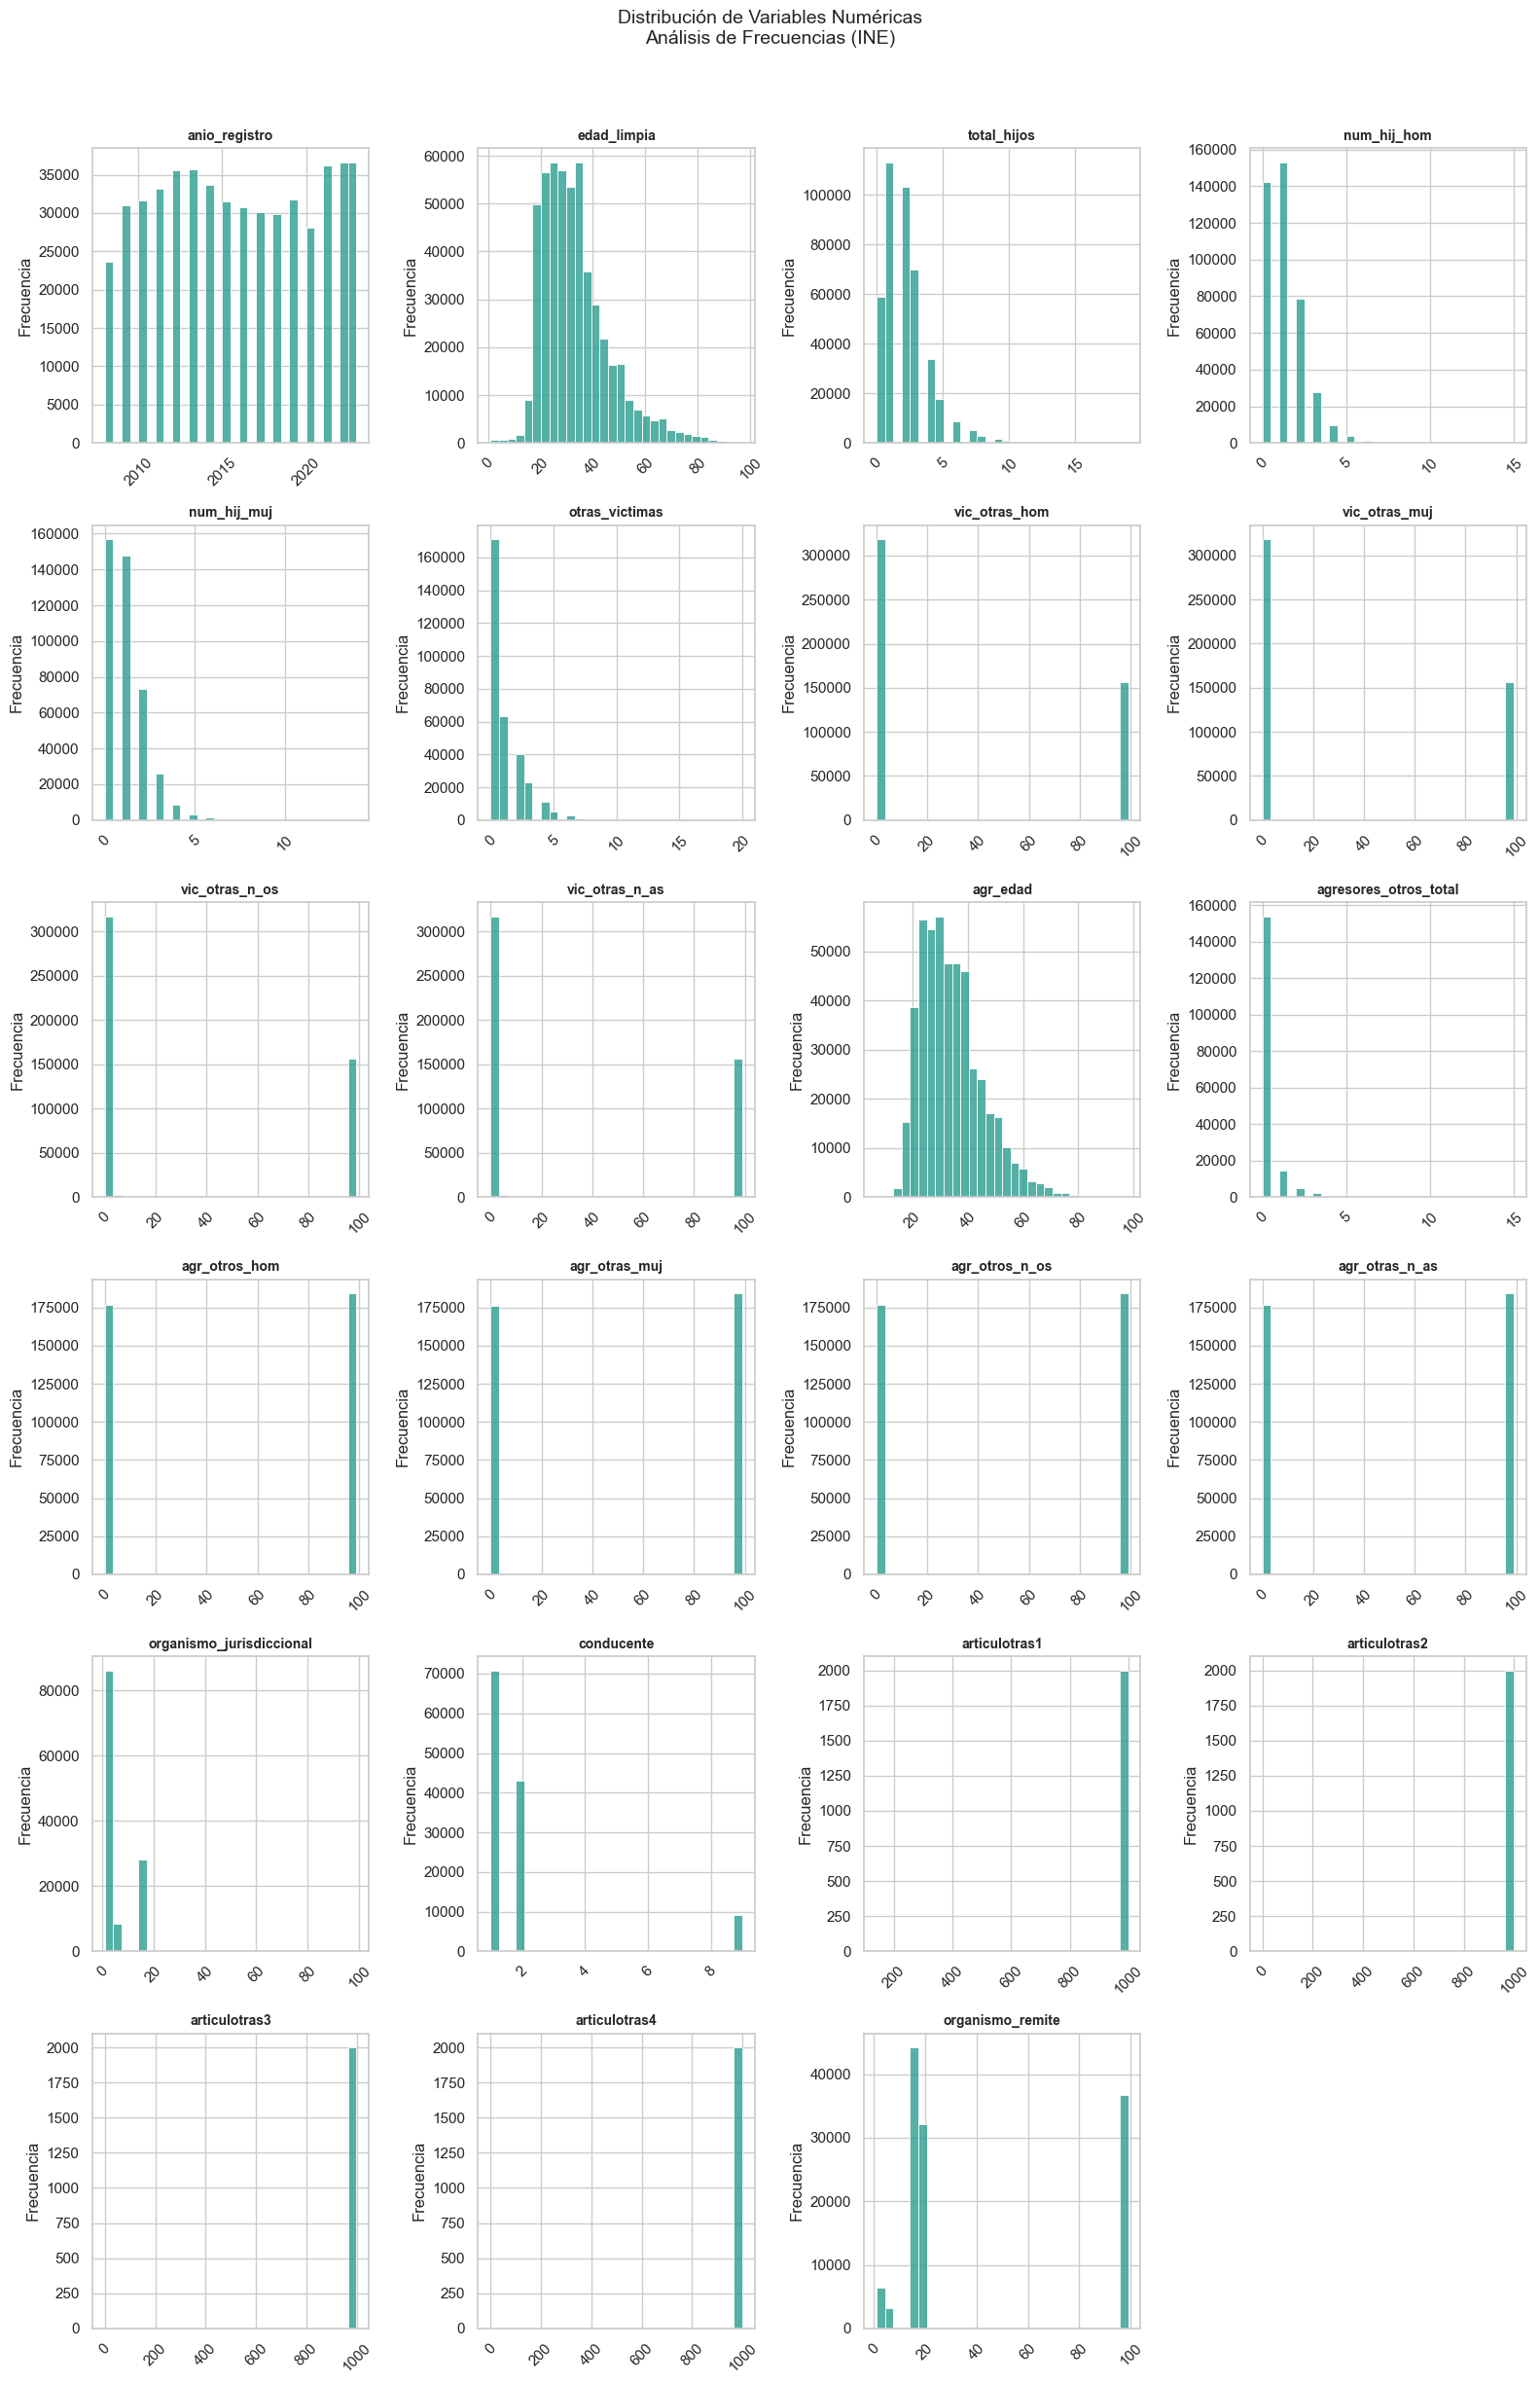

Resumen estadístico generado.


In [7]:
resumen_estadistico = generar_exploracion(df)
print("Resumen estadístico generado.")

## 4. Evaluación Preliminar de Normalidad

In [8]:
def prueba_normalidad(df):
    print("Generando Q-Q Plots...")
    df_muestra = df.sample(n=min(5000, len(df)), random_state=123)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    if "edad_limpia" in df_muestra.columns:
        stats.probplot(df_muestra["edad_limpia"].dropna(), dist="norm", plot=axes[0])
        axes[0].set_title("Q-Q Plot: Edad Víctima")
        axes[0].get_lines()[1].set_color("red")
    else:
        axes[0].set_title("edad_limpia no disponible")
        axes[0].text(0.5, 0.5, "Columna ausente", ha="center", va="center")

    if "total_hijos" in df_muestra.columns:
        stats.probplot(df_muestra["total_hijos"].dropna(), dist="norm", plot=axes[1])
        axes[1].set_title("Q-Q Plot: Total Hijos")
        axes[1].get_lines()[1].set_color("red")
    else:
        axes[1].set_title("total_hijos no disponible")
        axes[1].text(0.5, 0.5, "Columna ausente", ha="center", va="center")

    plt.tight_layout()
    plt.show()

Generando Q-Q Plots...


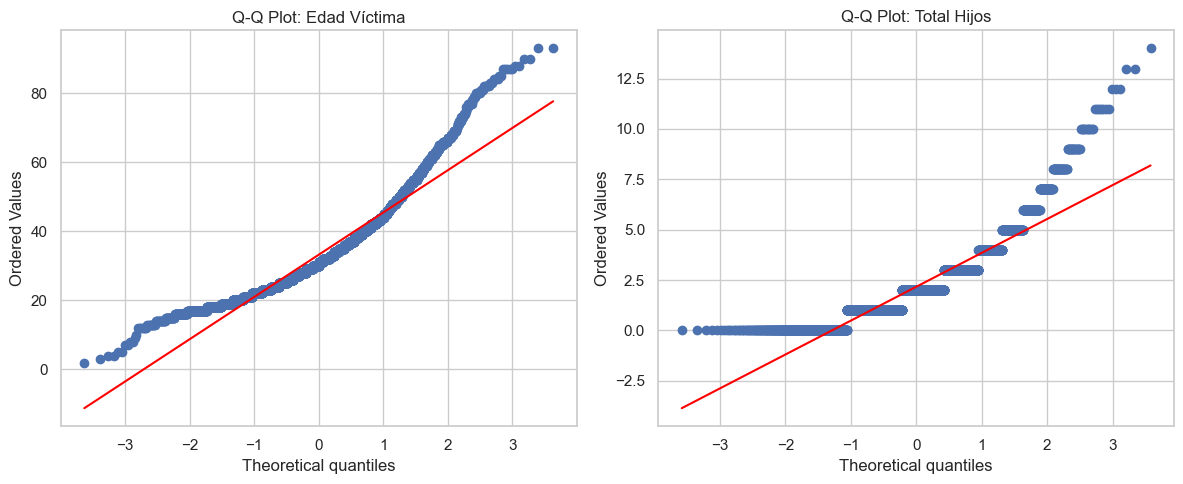

Q-Q plots generados.


In [9]:
prueba_normalidad(df)
print("Q-Q plots generados.")

## 5. Modelado No Supervisado: Clustering K-Means

In [10]:
def realizar_clustering(df):
    print("Preparando variables para clustering...")

    features_modelo = ["edad_limpia", "total_hijos", "vic_trabaja_num"]

    faltantes = [c for c in ["edad_limpia", "total_hijos", "vic_trabaja"] if c not in df.columns]
    if faltantes:
        raise ValueError(f"No se encontraron columnas requeridas para clustering: {faltantes}")

    df_cluster = df[["edad_limpia", "total_hijos", "vic_trabaja"]].copy()

    def _fix_mojibake_local(texto):
        if pd.isna(texto):
            return np.nan
        s = str(texto)
        if "Ã" in s or "Â" in s:
            try:
                return s.encode("latin1").decode("utf-8")
            except (UnicodeEncodeError, UnicodeDecodeError):
                return s
        return s

    # Mapeo robusto de vic_trabaja a numérico.
    vic_raw = df_cluster["vic_trabaja"].apply(_fix_mojibake_local).astype(str).str.strip().str.lower()
    mapa_trabaja = {
        "si": 1,
        "si trabaja por un salario o ingreso": 1,
        "sí": 1,
        "no": 0,
        "no trabaja por un salario o ingreso": 0,
        "no_especifica": 0,
    }
    df_cluster["vic_trabaja_num"] = vic_raw.map(mapa_trabaja)
    df_cluster["vic_trabaja_num"] = df_cluster["vic_trabaja_num"].fillna(0)

    # Se eliminan filas incompletas en las variables que alimentan el modelo.
    df_cluster = df_cluster.dropna(subset=["edad_limpia", "total_hijos"]).copy()

    scaler = StandardScaler()
    df_scaled = scaler.fit_transform(df_cluster[features_modelo])

    print("Ejecutando K-Means (k=3)...")
    kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
    df_cluster["Cluster"] = kmeans.fit_predict(df_scaled)

    centroides = pd.DataFrame(
        scaler.inverse_transform(kmeans.cluster_centers_),
        columns=features_modelo
    )
    centroides.index.name = "Cluster"

    print("\nCentroides de los clústeres (espacio escalado inverso):")
    display(centroides)

    # Visualización según clústeres multidimensionales.
    plt.figure(figsize=(8, 6))
    sns.scatterplot(
        x="edad_limpia",
        y="total_hijos",
        hue="Cluster",
        data=df_cluster,
        palette="viridis",
        alpha=0.5
    )
    plt.title("Segmentación de Perfiles de Víctimas")
    plt.tight_layout()
    plt.show()

    return df_cluster, centroides

Preparando variables para clustering...
Ejecutando K-Means (k=3)...

Centroides de los clústeres (espacio escalado inverso):


,edad_limpia,total_hijos,vic_trabaja_num
Cluster,,,
0,32.955008,1.831832,1.000000e+00
1,49.471030,4.579173,1.634945e-01
2,27.554473,1.525342,2.026157e-14


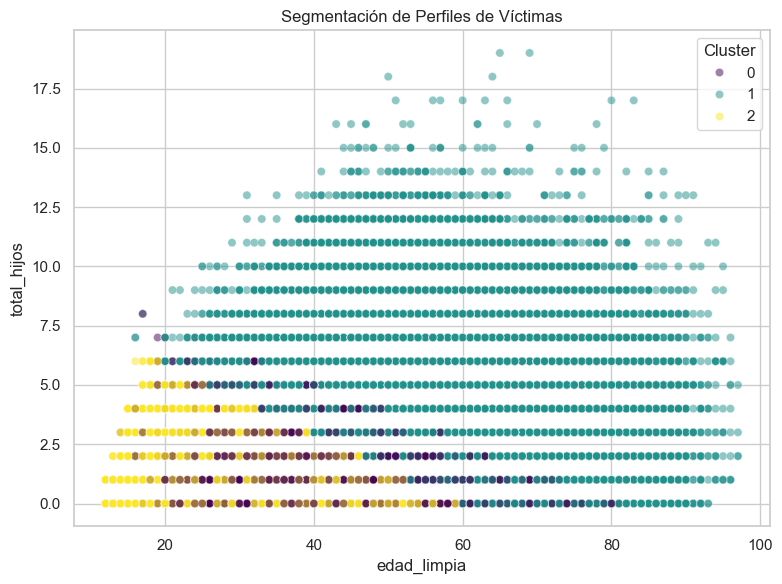

Clustering realizado.


In [11]:
df_cluster, centroides = realizar_clustering(df)
print("Clustering realizado.")

## 6. Síntesis de Resultados

En las celdas de código anteriores, se unificó el proceso completo de análisis:
- Carga y limpieza desde el archivo CSV principal.
- Exploración estadística y visualización de distribuciones.
- Evaluación de normalidad para variables clave.
- Segmentación con K-Means y visualización de centroides y clústeres dentro del cuaderno.

## 7. Preparación de Datos para Modelado Supervisado

En este apartado se construye una variable respuesta binaria para estimar riesgo de violencia física y se prepara una matriz de predictores para modelos de clasificación.

### Paso 1. Transformación de la Variable Respuesta (Binarización)

Criterio aplicado sobre hec_tipagre (normalizando tildes y corrigiendo posibles errores de codificación como PsicolÃ³gica):
- Se asigna 1 si la categoría pertenece a un tipo que incluye **violencia física o sexual**.
- Se asigna 0 únicamente si la categoría corresponde a violencia sin contacto físico directo: psicológica o patrimonial.
- Valores nulos y categorías fuera de este conjunto (por ejemplo, Otros) se asignan como NaN para excluirse del entrenamiento supervisado.

In [12]:
import unicodedata

def reparar_mojibake(texto):
    if pd.isna(texto):
        return np.nan
    s = str(texto)
    # Corrige casos típicos como 'PsicolÃ³gica' -> 'Psicológica'.
    if "Ã" in s or "Â" in s:
        try:
            return s.encode("latin1").decode("utf-8")
        except (UnicodeEncodeError, UnicodeDecodeError):
            return s
    return s

def normalizar_texto_categoria(x):
    if pd.isna(x):
        return np.nan
    txt = reparar_mojibake(x)
    txt = str(txt).strip().lower()
    txt = "".join(ch for ch in unicodedata.normalize("NFKD", txt) if not unicodedata.combining(ch))
    txt = re.sub(r"\s+", " ", txt)
    return txt

# Clase 1: cualquier combinación con componente física o sexual.
categorias_riesgo_alto = {
    "fisica",
    "sexual",
    "fisica-psicologica",
    "fisica-sexual",
    "fisica-patrimonial",
    "psicologica-sexual",
    "sexual-patrimonial",
    "fisica-psicologica-sexual",
    "fisica-psicologica-patrimonial",
    "psicologica-sexual-patrimonial",
    "fisica-sexual-patrimonial",
    "fisica-psicologica-sexual-patrimonial",
}

# Clase 0: violencia sin contacto físico directo.
categorias_riesgo_bajo = {
    "psicologica",
    "patrimonial",
    "psicologica-patrimonial",
}

hec_norm = df["hec_tipagre"].apply(normalizar_texto_categoria)

# Valores fuera del esquema (incluye 'otros') y nulos quedan como NaN.
df["riesgo_violencia_fisica"] = np.select(
    [hec_norm.isin(categorias_riesgo_alto), hec_norm.isin(categorias_riesgo_bajo)],
    [1, 0],
    default=np.nan
)

print("Distribución de riesgo_violencia_fisica (incluye NaN):")
display(df["riesgo_violencia_fisica"].value_counts(dropna=False).rename("conteo").to_frame())



Distribución de riesgo_violencia_fisica (incluye NaN):


,conteo
riesgo_violencia_fisica,
1.0,300440
0.0,215506


Grafica de distribución:

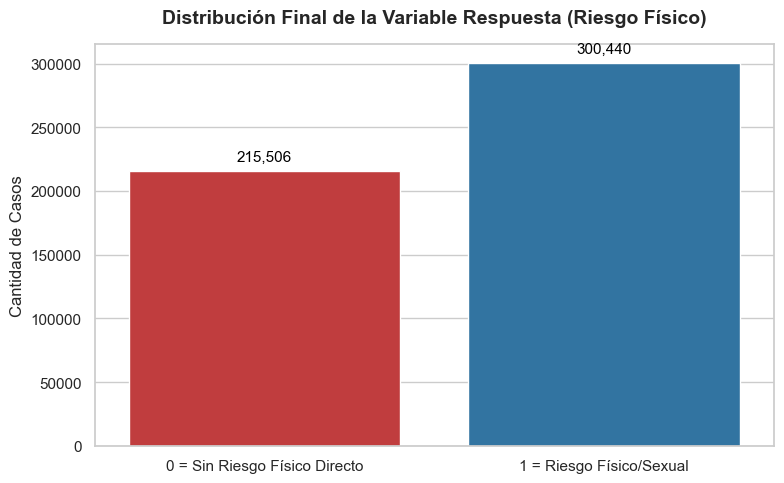

In [13]:
plot_df = df[["riesgo_violencia_fisica"]].dropna().copy()
plot_df["riesgo_violencia_fisica"] = plot_df["riesgo_violencia_fisica"].astype(int)

plot_df["Clase"] = plot_df["riesgo_violencia_fisica"].map({
    0: "0 = Sin Riesgo Físico Directo",
    1: "1 = Riesgo Físico/Sexual"
})

plt.figure(figsize=(8, 5))
sns.set_theme(style="whitegrid")

# Crear el gráfico de barras
ax = sns.countplot(
    data=plot_df,
    x="Clase",
    order=["0 = Sin Riesgo Físico Directo", "1 = Riesgo Físico/Sexual"],
    hue="Clase",                   
    palette=["#1f77b4", "#d62728"],
    legend=False                   
)

# Títulos y ejes
plt.title("Distribución Final de la Variable Respuesta (Riesgo Físico)", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("")
plt.ylabel("Cantidad de Casos", fontsize=12)

# Agregar los números arriba de cada barra
for p in ax.patches:
    altura = p.get_height()
    ax.annotate(f"{int(altura):,}", 
                (p.get_x() + p.get_width() / 2., altura),
                ha='center', va='bottom', fontsize=11, color='black', 
                xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

### Paso 2. Selección de Variables Predictoras (Features)

Se retienen únicamente la variable respuesta y los predictores definidos para el problema supervisado.
En este paso, `total_hijos` se imputa con `0` (ausencia de hijos como hipótesis de trabajo), mientras que `edad_limpia` y `agr_edad` se imputan con mediana.

In [14]:
columnas_modelo = [
    "riesgo_violencia_fisica",
    "edad_limpia",
    "total_hijos",
    "agr_edad",
    "vic_rel_agr",
    "vic_trabaja",
    "hec_recur_denun",
]

df_modelo = df[columnas_modelo].copy()

# Para modelado supervisado se excluyen registros sin etiqueta binaria válida.
df_modelo = df_modelo.dropna(subset=["riesgo_violencia_fisica"]).copy()
df_modelo["riesgo_violencia_fisica"] = df_modelo["riesgo_violencia_fisica"].astype(int)

variables_numericas = ["edad_limpia", "total_hijos", "agr_edad"]

print("Faltantes numéricos antes de imputación:")
display(df_modelo[variables_numericas].isna().sum().rename("nulos").to_frame())

# Regla específica para total_hijos: nulos -> 0
df_modelo["total_hijos"] = df_modelo["total_hijos"].fillna(0)

# Para edad_limpia y agr_edad se usa imputación por mediana.
for col in ["edad_limpia", "agr_edad"]:
    df_modelo[col] = df_modelo[col].fillna(df_modelo[col].median())

# Transformación de recurrencia de denuncia: Si -> 1, No -> 0, nulos -> 0.
mapa_recurrencia = {"si": 1, "no": 0}
df_modelo["hec_recur_denun"] = (
    df_modelo["hec_recur_denun"]
    .apply(reparar_mojibake)
    .astype(str)
    .str.strip()
    .str.lower()
    .map(mapa_recurrencia)
    .fillna(0)
    .astype(int)
)

# Reutilización de la etiqueta de clúster desde df_cluster por índice (left join).
df_modelo = df_modelo.join(df_cluster[["Cluster"]], how="left")
df_modelo["Cluster"] = df_modelo["Cluster"].fillna(-1).astype(int).astype(str)
df_modelo["Cluster"] = df_modelo["Cluster"].replace({"-1": "Sin_Cluster"})

print("Faltantes numéricos después de imputación:")
display(df_modelo[variables_numericas].isna().sum().rename("nulos").to_frame())

print("Distribución de hec_recur_denun:")
display(df_modelo["hec_recur_denun"].value_counts(dropna=False).rename("conteo").to_frame())

print("Distribución de Cluster (con Sin_Cluster):")
display(df_modelo["Cluster"].value_counts(dropna=False).rename("conteo").to_frame())

print("Dimensión del dataset para modelado:", df_modelo.shape)
display(df_modelo.head())

Faltantes numéricos antes de imputación:


,nulos
edad_limpia,6927
total_hijos,98320
agr_edad,33565


Faltantes numéricos después de imputación:


,nulos
edad_limpia,0
total_hijos,0
agr_edad,0


Distribución de hec_recur_denun:


,conteo
hec_recur_denun,
0,454621
1,61325


Distribución de Cluster (con Sin_Cluster):


,conteo
Cluster,
2,212793
0,127224
Sin_Cluster,102110
1,73819


Dimensión del dataset para modelado: (515946, 8)


,riesgo_violencia_fisica,edad_limpia,total_hijos,agr_edad,vic_rel_agr,vic_trabaja,hec_recur_denun,Cluster
0,1,21.0,2.0,25.0,Conviviente,Si trabaja por un salario o ingreso,0,0
1,1,43.0,3.0,32.0,Esposos(a),Si trabaja por un salario o ingreso,0,0
2,0,43.0,2.0,41.0,Ex-cónyuges,Si trabaja por un salario o ingreso,1,0
3,1,35.0,3.0,35.0,Esposos(a),No trabaja por un salario o ingreso,0,2
4,1,26.0,3.0,27.0,Esposos(a),No trabaja por un salario o ingreso,0,2


### Paso 3 y 4. Escalamiento Numérico y Encoding Categórico

Se utiliza **MinMaxScaler** porque en el análisis exploratorio las variables numéricas no siguen normalidad; este escalador no asume distribución normal y lleva cada variable al rango [0, 1], facilitando comparabilidad para modelos lineales y basados en distancia.

In [15]:
variables_numericas = ["edad_limpia", "total_hijos", "agr_edad"]
variables_binarias = ["hec_recur_denun"]
variables_categoricas = ["vic_rel_agr", "vic_trabaja", "Cluster"]

df_prep = df_modelo.copy()

# Elegimos MinMaxScaler por no requerir normalidad y acotar escala a [0, 1].
scaler = MinMaxScaler()
df_prep[variables_numericas] = scaler.fit_transform(df_prep[variables_numericas])

def normalizar_texto_cat(valor):
    if pd.isna(valor):
        return ""
    txt = reparar_mojibake(valor)
    txt = str(txt).strip().lower()
    txt = "".join(ch for ch in unicodedata.normalize("NFKD", txt) if not unicodedata.combining(ch))
    txt = re.sub(r"\s+", " ", txt)
    return txt

def agrupar_vic_rel_agr(valor):
    txt = normalizar_texto_cat(valor)

    grupo_pareja = {
        "esposos (a)",
        "esposos(a)",
        "esposos (as)",
        "esposos(as)",
        "conviviente",
        "ex-conyuges",
        "ex conyuges",
    }
    grupo_familia = {
        "padres/madres",
        "hijos(as)",
        "hermanos(as)",
        "nietos(as)",
        "suegros(as)",
        "hijastros(as)",
        "otro pariente",
    }

    if txt in grupo_pareja:
        return "Pareja"
    if txt in grupo_familia:
        return "Familia"
    return "Otros"

def estandarizar_vic_trabaja(valor):
    txt = normalizar_texto_cat(valor)

    categoria_si = {
        "si",
        "sí",
        "si trabaja por un salario o ingreso",
        "si trabaja por salario o ingreso",
    }
    categoria_no = {
        "no",
        "no trabaja por un salario o ingreso",
        "no trabaja por salario o ingreso",
    }

    if txt in categoria_si:
        return "Si"
    if txt in categoria_no:
        return "No"
    return "No_especifica"

# Agrupación de vic_rel_agr en tres macrogrupos: Pareja, Familia y Otros.
df_prep["vic_rel_agr"] = df_prep["vic_rel_agr"].apply(agrupar_vic_rel_agr)

# Normalización robusta de vic_trabaja
df_prep["vic_trabaja"] = df_prep["vic_trabaja"].apply(estandarizar_vic_trabaja)

# Cluster se mantiene como categórica para pasar por One-Hot Encoding.
df_prep["Cluster"] = df_prep["Cluster"].fillna("Sin_Cluster").astype(str)

# Forzamos 3 categorías en las variables clave para controlar el número de dummies con drop_first=True.
df_prep["vic_rel_agr"] = pd.Categorical(
    df_prep["vic_rel_agr"],
    categories=["Pareja", "Familia", "Otros"]
)
df_prep["vic_trabaja"] = pd.Categorical(
    df_prep["vic_trabaja"],
    categories=["No", "Si", "No_especifica"]
)

# En categóricas, convertimos nulos a etiqueta.
for col in variables_categoricas:
    df_prep[col] = df_prep[col].fillna("No_especifica")

X = pd.get_dummies(
    df_prep[variables_numericas + variables_binarias + variables_categoricas],
    columns=variables_categoricas,
    drop_first=True,
    dtype=int
)
y = df_prep["riesgo_violencia_fisica"]

dummies_vic_trabaja = [c for c in X.columns if c.startswith("vic_trabaja_")]
dummies_vic_rel_agr = [c for c in X.columns if c.startswith("vic_rel_agr_")]

print("Matriz de predictores X:", X.shape)
print("Vector respuesta y:", y.shape)
print("Categorías vic_trabaja normalizadas:", list(df_prep["vic_trabaja"].cat.categories))
print("Categorías vic_rel_agr agrupadas:", list(df_prep["vic_rel_agr"].cat.categories))
print("Dummies vic_trabaja:", len(dummies_vic_trabaja), dummies_vic_trabaja)
print("Dummies vic_rel_agr:", len(dummies_vic_rel_agr), dummies_vic_rel_agr)
display(X.head())

print("Columnas generadas en X:")
display(pd.DataFrame({"columna": X.columns}).head(140))
display(y.value_counts().rename("conteo").to_frame())

Matriz de predictores X: (515946, 11)
Vector respuesta y: (515946,)
Categorías vic_trabaja normalizadas: ['No', 'Si', 'No_especifica']
Categorías vic_rel_agr agrupadas: ['Pareja', 'Familia', 'Otros']
Dummies vic_trabaja: 2 ['vic_trabaja_Si', 'vic_trabaja_No_especifica']
Dummies vic_rel_agr: 2 ['vic_rel_agr_Familia', 'vic_rel_agr_Otros']


,edad_limpia,total_hijos,agr_edad,hec_recur_denun,vic_rel_agr_Familia,vic_rel_agr_Otros,vic_trabaja_Si,vic_trabaja_No_especifica,Cluster_1,Cluster_2,Cluster_Sin_Cluster
0,0.208333,0.105263,0.197802,0,0,0,1,0,0,0,0
1,0.437500,0.157895,0.274725,0,0,0,1,0,0,0,0
2,0.437500,0.105263,0.373626,1,0,0,1,0,0,0,0
3,0.354167,0.157895,0.307692,0,0,0,0,0,0,1,0
4,0.260417,0.157895,0.219780,0,0,0,0,0,0,1,0


Columnas generadas en X:


,columna
0,edad_limpia
1,total_hijos
2,agr_edad
3,hec_recur_denun
4,vic_rel_agr_Familia
5,vic_rel_agr_Otros
6,vic_trabaja_Si
7,vic_trabaja_No_especifica
8,Cluster_1
9,Cluster_2


,conteo
riesgo_violencia_fisica,
1,300440
0,215506


## Modelado Supervisado: Entrenamiento y Evaluación

Se entrenan cuatro clasificadores sobre la matriz `X` y el vector respuesta `y` obtenidos en la sección anterior:
- **CART** (Árbol de Decisión): interpretable, permite visualizar reglas.
- **Random Forest**: conjunto de árboles, reduce varianza.
- **KNN** (k vecinos más cercanos): basado en distancia, sensible a escala.
- **Regresión Logística**: modelo lineal, coeficientes interpretables.

División: 70 % entrenamiento / 30 % prueba con estratificación.

### Paso 5. División Train / Test

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]:,} filas  |  Test: {X_test.shape[0]:,} filas")
print(f"Proporción clase 1 en train: {y_train.mean():.3f}")
print(f"Proporción clase 1 en test:  {y_test.mean():.3f}")

Train: 361,162 filas  |  Test: 154,784 filas
Proporción clase 1 en train: 0.582
Proporción clase 1 en test:  0.582


### Paso 6. Entrenamiento de los Cuatro Modelos

In [17]:
import warnings
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

warnings.filterwarnings("ignore")

modelos = {
    "CART": DecisionTreeClassifier(max_depth=6, min_samples_leaf=50, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1),
    "KNN": KNeighborsClassifier(n_neighbors=11, n_jobs=-1),
    "Regresión Logística": LogisticRegression(max_iter=500, random_state=42),
}

for nombre, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    print(f"{nombre} entrenado.")

CART entrenado.
Random Forest entrenado.
KNN entrenado.
Regresión Logística entrenado.


### Paso 7. Evaluación: Classification Report y Accuracy

In [18]:
from sklearn.metrics import classification_report, accuracy_score

resumen_modelos = []

for nombre, modelo in modelos.items():
    y_pred = modelo.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    resumen_modelos.append({"Modelo": nombre, "Accuracy": acc})
    print(f"  Modelo: {nombre}  |  Accuracy: {acc:.4f}")
    print('-'*55)
    print(classification_report(y_test, y_pred, target_names=["No físico (0)", "Físico (1)"]))

df_resumen = pd.DataFrame(resumen_modelos).sort_values("Accuracy", ascending=False)
display(df_resumen.reset_index(drop=True))

  Modelo: CART  |  Accuracy: 0.6125
-------------------------------------------------------
               precision    recall  f1-score   support

No físico (0)       0.56      0.32      0.41     64652
   Físico (1)       0.63      0.82      0.71     90132

     accuracy                           0.61    154784
    macro avg       0.60      0.57      0.56    154784
 weighted avg       0.60      0.61      0.59    154784

  Modelo: Random Forest  |  Accuracy: 0.6152
-------------------------------------------------------
               precision    recall  f1-score   support

No físico (0)       0.57      0.33      0.41     64652
   Físico (1)       0.63      0.82      0.71     90132

     accuracy                           0.62    154784
    macro avg       0.60      0.57      0.56    154784
 weighted avg       0.60      0.62      0.59    154784

  Modelo: KNN  |  Accuracy: 0.5788
-------------------------------------------------------
               precision    recall  f1-score   sup

,Modelo,Accuracy
0,Random Forest,0.615154
1,CART,0.612473
2,Regresión Logística,0.607046
3,KNN,0.578774


### Paso 8. Comparativa Visual de Accuracy

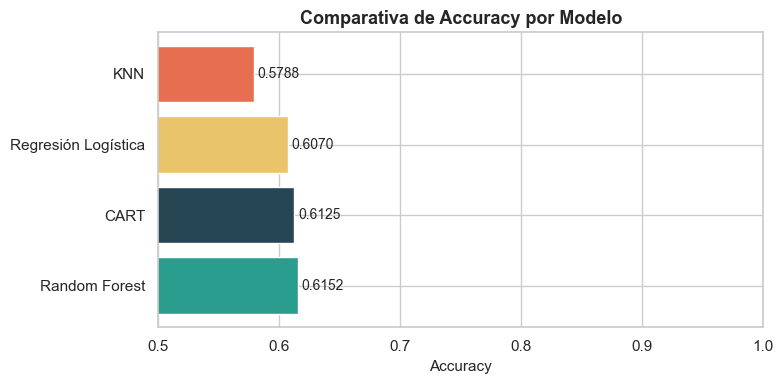

In [19]:
fig, ax = plt.subplots(figsize=(8, 4))
colores = ["#2A9D8F", "#264653", "#E9C46A", "#E76F51"]
bars = ax.barh(
    df_resumen["Modelo"],
    df_resumen["Accuracy"],
    color=colores[:len(df_resumen)],
    edgecolor="white"
)
ax.set_xlim(0.5, 1.0)
ax.set_xlabel("Accuracy", fontsize=11)
ax.set_title("Comparativa de Accuracy por Modelo", fontsize=13, fontweight="bold")
for bar, val in zip(bars, df_resumen["Accuracy"]):
    ax.text(val + 0.003, bar.get_y() + bar.get_height()/2,
            f"{val:.4f}", va="center", fontsize=10)
plt.tight_layout()
plt.show()

### Paso 9. Matrices de Confusión

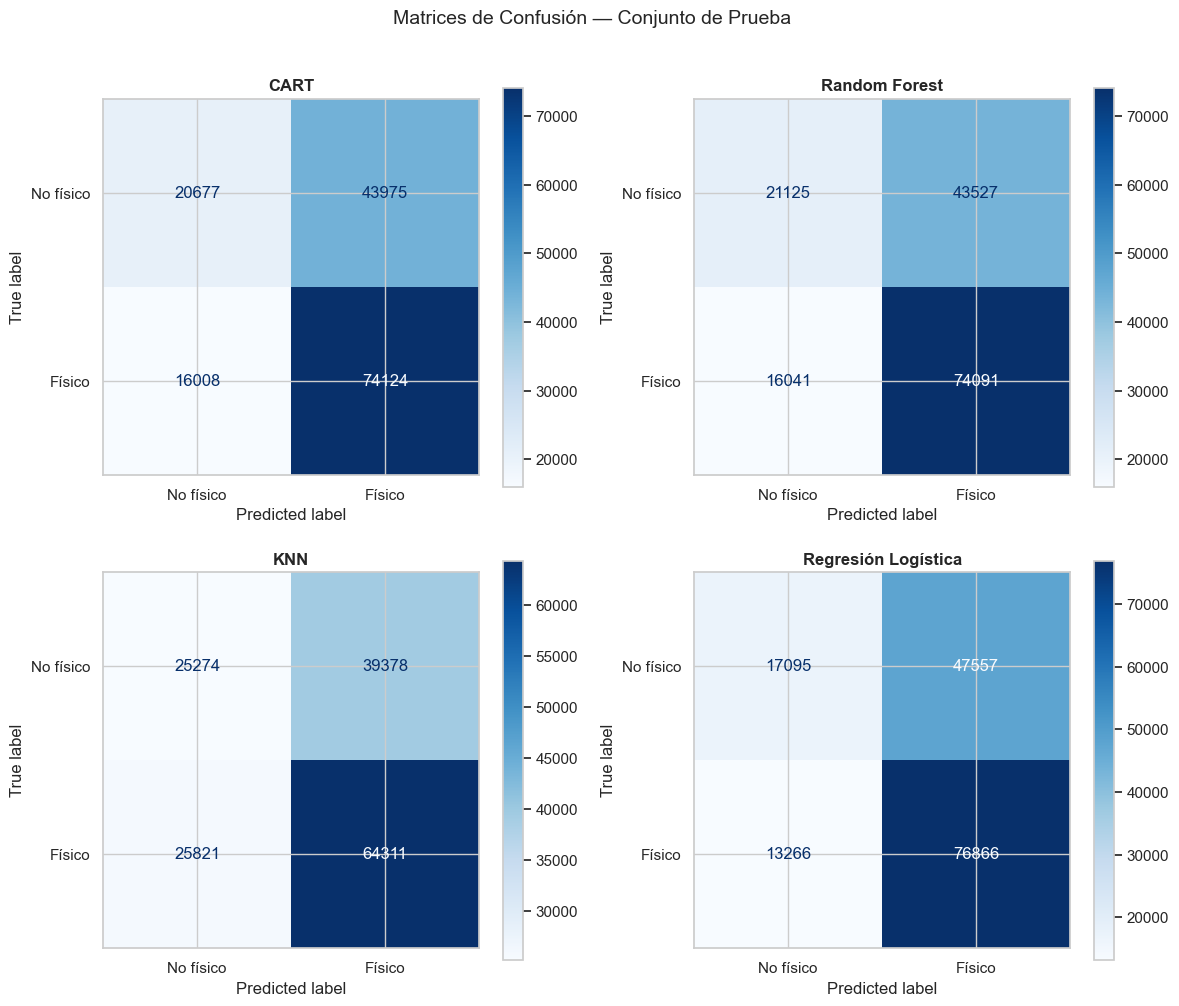

In [20]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, (nombre, modelo) in zip(axes, modelos.items()):
    y_pred = modelo.predict(X_test)
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred,
        display_labels=["No físico", "Físico"],
        cmap="Blues",
        ax=ax
    )
    ax.set_title(nombre, fontweight="bold")

plt.suptitle("Matrices de Confusión — Conjunto de Prueba", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### Paso 10. Importancia de Variables (CART y Random Forest)

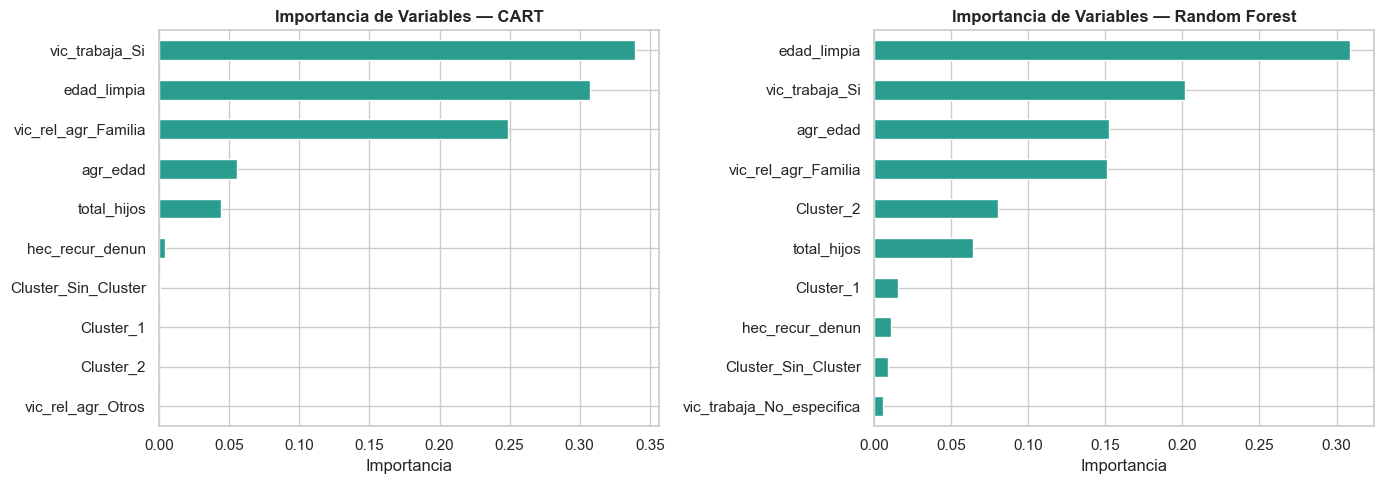

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, nombre in zip(axes, ["CART", "Random Forest"]):
    imp = pd.Series(
        modelos[nombre].feature_importances_,
        index=X.columns
    ).sort_values()
    imp.tail(10).plot(kind="barh", ax=ax, color="#2A9D8F", edgecolor="white")
    ax.set_title(f"Importancia de Variables — {nombre}", fontweight="bold")
    ax.set_xlabel("Importancia")

plt.tight_layout()
plt.show()

### Paso 11. Visualización del Árbol CART (profundidad 3)

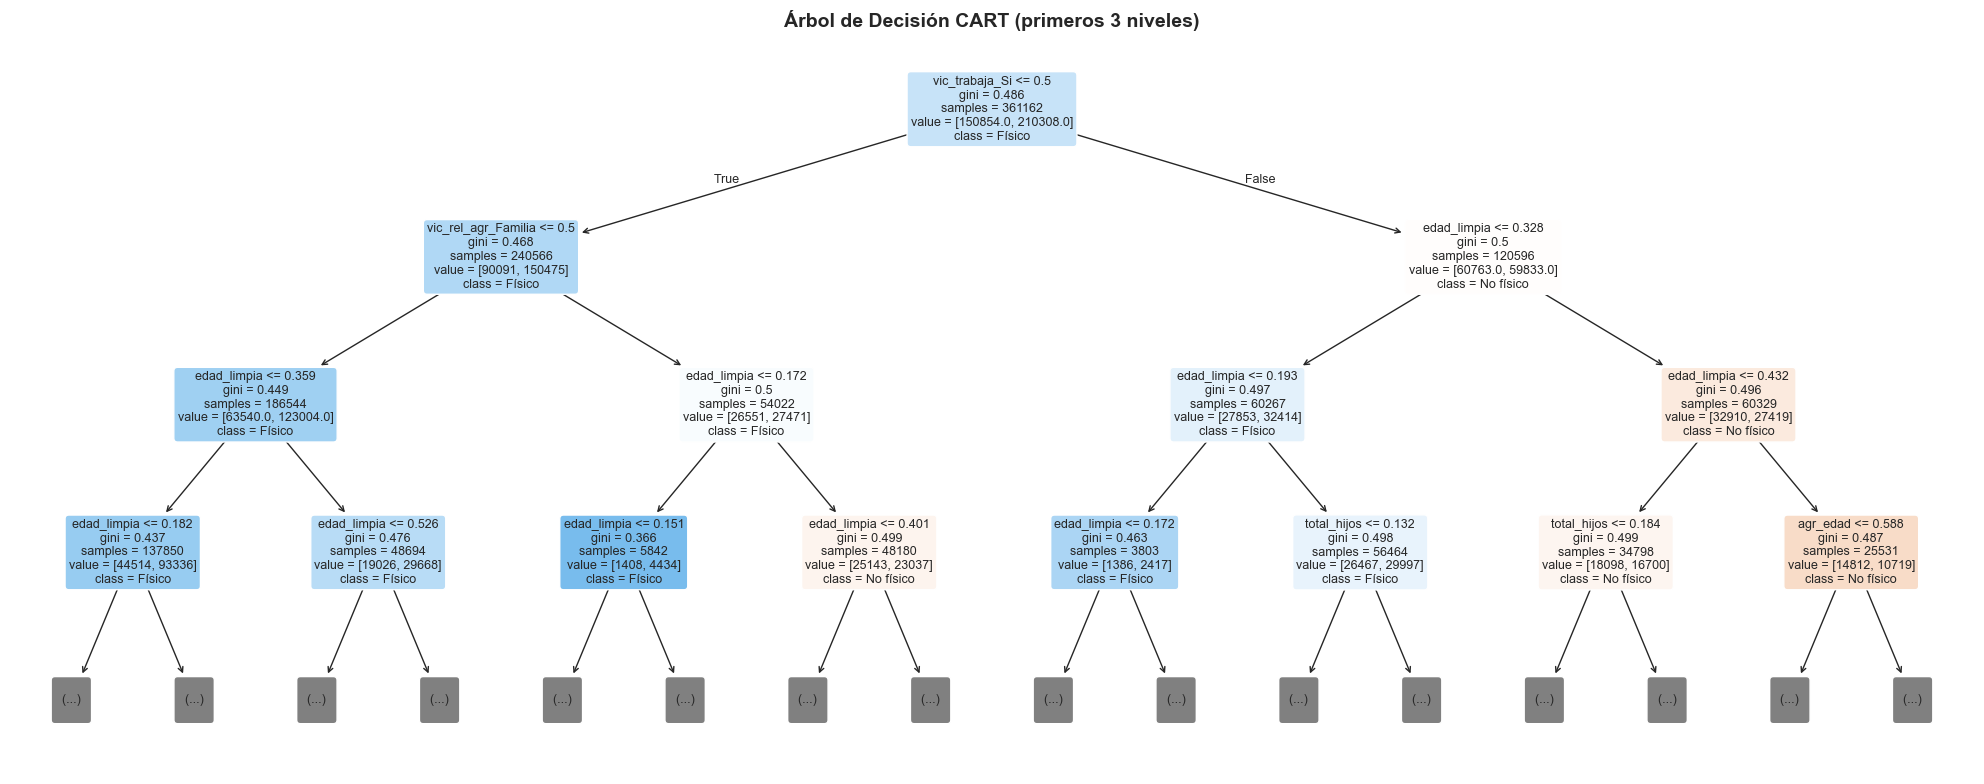

In [22]:
from sklearn.tree import plot_tree

fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(
    modelos["CART"],
    max_depth=3,
    feature_names=list(X.columns),
    class_names=["No físico", "Físico"],
    filled=True,
    rounded=True,
    fontsize=9,
    ax=ax
)
ax.set_title("Árbol de Decisión CART (primeros 3 niveles)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### Paso 12. Curvas ROC

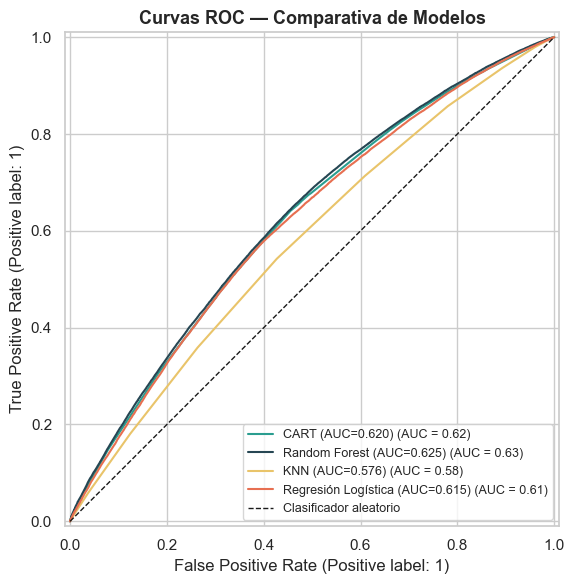

In [23]:
from sklearn.metrics import RocCurveDisplay, roc_auc_score

fig, ax = plt.subplots(figsize=(8, 6))
colores_roc = ["#2A9D8F", "#264653", "#E9C46A", "#E76F51"]

for (nombre, modelo), color in zip(modelos.items(), colores_roc):
    if hasattr(modelo, "predict_proba"):
        y_prob = modelo.predict_proba(X_test)[:, 1]
    else:
        y_prob = modelo.decision_function(X_test)
    auc = roc_auc_score(y_test, y_prob)
    RocCurveDisplay.from_predictions(
        y_test, y_prob,
        name=f"{nombre} (AUC={auc:.3f})",
        color=color,
        ax=ax
    )

ax.plot([0, 1], [0, 1], "k--", lw=1, label="Clasificador aleatorio")
ax.set_title("Curvas ROC — Comparativa de Modelos", fontsize=13, fontweight="bold")
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()

##### Conclusiones del Modelado Inicial

Las celdas anteriores completan el flujo supervisado:
1. **División** estratificada 70/30 para preservar la proporción de clases.
2. **Entrenamiento** de CART, Random Forest, KNN y Regresión Logística sobre la misma matriz `X`.
3. **Evaluación** con accuracy, reporte de clasificación (precision/recall/F1), matrices de confusión y curvas ROC-AUC.
4. **Interpretabilidad**: importancia de variables en modelos basados en árboles y visualización del árbol CART a profundidad 3.

> La variable respuesta `riesgo_violencia_fisica` se construyó en el Paso 1 normalizando tildes y corrigiendo mojibake, asignando **1** a categorías con componente física o sexual, **0** a violencia exclusivamente psicológica/patrimonial, y **NaN** a categorías ambiguas o nulas, que se excluyen del entrenamiento.

## **Avances 3: Modelos con un algoritmo**

En esta sección se documenta el proceso completo de modelado supervisado predictivo sobre los datos de violencia intrafamiliar del INE de Guatemala.

El trabajo continua directamente de los Avances 1 y 2, cuyo análisis exploratorio, segmentación K-Means y evaluación comparativa de algoritmos constituyen la base.

## 1. Variable Respuesta

La variable respuesta del modelo es **`riesgo_violencia_fisica`**, de tipo **categórica binaria**. Su construcción partió de la columna original `hec_tipagre` (tipología de la violencia cometida), cuyo procesamiento exigió una serie de decisiones y transformaciones que se documentan a continuación.

---

### Origen y naturaleza de la variable fuente

`hec_tipagre` contiene la tipología de la agresión tal como fue registrada por la institución receptora de la denuncia (Ministerio Público, Policía Nacional Civil, Juzgados, etc.). En la base unificada del INE se identificaron **más de 12 categorías originales**, entre ellas: *Física*, *Psicológica*, *Física-Psicológica*, *Patrimonial*, *Sexual*, *Física-Psicológica-Patrimonial*, *Psicológica-Patrimonial*, entre otras combinaciones. La variable es de tipo texto libre y presentó **dos problemas sistemáticos de calidad**:

1. **Errores de codificación (*mojibake*):** Caracteres especiales del español (tildes, ñ) aparecían corruptos en algunos registros, por ejemplo `PsicolÃ³gica` en lugar de `Psicológica`. Esto hacía que una misma categoría semántica tuviera múltiples representaciones distintas en el sistema.
2. **Inconsistencias de formato:** Espacios adicionales, variaciones en mayúsculas/minúsculas y diferencias en el uso de guiones (`-`) entre términos.

---

### Transformaciones aplicadas paso a paso

**Paso 1 — Corrección de mojibake:**
Se aplicó la función `reparar_mojibake`, que detecta secuencias de bytes mal interpretados (presencia de `Ã` o `Â` en el texto) y recodifica el string de Latin-1 a UTF-8. Esto normalizó categorías como `PsicolÃ³gica` → `Psicológica`.

**Paso 2 — Normalización de texto:**
Cada valor fue procesado con `normalizar_texto_categoria`, que ejecuta tres operaciones en cadena: 
<ol type="a">
 <li> conversión a minúsculas</li>
 <li> eliminación de tildes mediante descomposición Unicode (NFKD) y remoción de caracteres combinantes</li>
 <li> colapso de espacios múltiples</li>
</ol>
El resultado fue un conjunto de etiquetas del tipo `fisica-psicologica`, `psicologica-patrimonial`, etc., libre de ambigüedad tipográfica.

**Paso 3 — Binarización bajo criterio de riesgo de contacto físico:**
Una vez normalizadas las etiquetas, se definieron dos conjuntos mutuamente excluyentes con base en un criterio institucional de riesgo:

- **Clase 1 — Riesgo físico/sexual (300,440 registros):** Todas las tipologías que implican contacto físico directo o agresión sexual, independientemente de si van acompañadas de violencia psicológica o patrimonial. Comprende: *fisica*, *sexual*, *fisica-psicologica*, *fisica-sexual*, *fisica-patrimonial*, *psicologica-sexual*, *sexual-patrimonial*, *fisica-psicologica-sexual*, *fisica-psicologica-patrimonial*, *psicologica-sexual-patrimonial*, *fisica-sexual-patrimonial* y *fisica-psicologica-sexual-patrimonial*. Representa los escenarios de mayor peligro inmediato para la integridad física de la víctima.

- **Clase 0 — Sin riesgo físico directo (215,506 registros):** Agresiones de naturaleza estrictamente emocional o económica, sin componente de contacto físico reportado: *psicologica*, *patrimonial* y *psicologica-patrimonial*.

**Paso 4 — Tratamiento de casos ambiguos y nulos:**
Los registros con categorías fuera del esquema binario (como *Otros*) y los valores nulos de `hec_tipagre` fueron asignados como `NaN` y **excluidos del proceso de entrenamiento supervisado**. Esta decisión es deliberada, ya que incluirlos bajo alguna de las dos clases introduciría ruido semántico, pues no es posible determinar con certeza el tipo de riesgo que representan bajo el criterio definido. 
El modelo opera únicamente sobre los 515,946 registros con etiqueta binaria válida.

**Paso 5 — Análisis de atípicos:**
Dado que `riesgo_violencia_fisica` es una **variable categórica binaria**, el concepto de valor atípico (*outlier*) no aplica en este contexto. Los outliers son una propiedad de distribuciones numéricas continuas. En variables de clasificación binaria, lo que se analiza es el **balance de clases**, no la presencia de valores extremos.

---

### Justificación de la variable seleccionada

El análisis exploratorio previo (Primera entrega) evidenció que la naturaleza del vínculo entre víctima y agresor, y no los atributos demográficos aislados de la víctima, es el principal determinante del tipo de violencia ejercida. Sin embargo, detectar si un caso involucra violencia física resulta crítico para la **priorización institucional**, ya que este tipo de violencia requiere intervención inmediata y puede tener consecuencias irreversibles para la víctima. 

Por esta razón, se optó por construir un indicador de riesgo operacional orientado a apoyar la toma de decisiones en instituciones como el Ministerio Público o la Policía Nacional Civil, y no únicamente a clasificar tipologías como ejercicio académico.

---

### Balance de clases resultante

| Clase | Descripción | Registros | Proporción |
|-------|-------------|:---------:|:----------:|
| 1 | Riesgo físico/sexual | 300,440 | 58.2% |
| 0 | Sin riesgo físico directo | 215,506 | 41.8% |
| NaN | Excluidos (ambiguos/nulos) | — | — |

Si bien el desbalance no es severo (~16 puntos porcentuales entre clases, una diferencia de 84,934 registros), es suficiente para inducir un sesgo hacia la clase mayoritaria en todos los modelos evaluados, generando un recall alto para la Clase 1 y bajo para la Clase 0. Para mitigar este efecto, se aplicó el parámetro `class_weight='balanced'` en todos los algoritmos entrenados, que pondera cada observación de forma inversamente proporcional a la frecuencia de su clase.


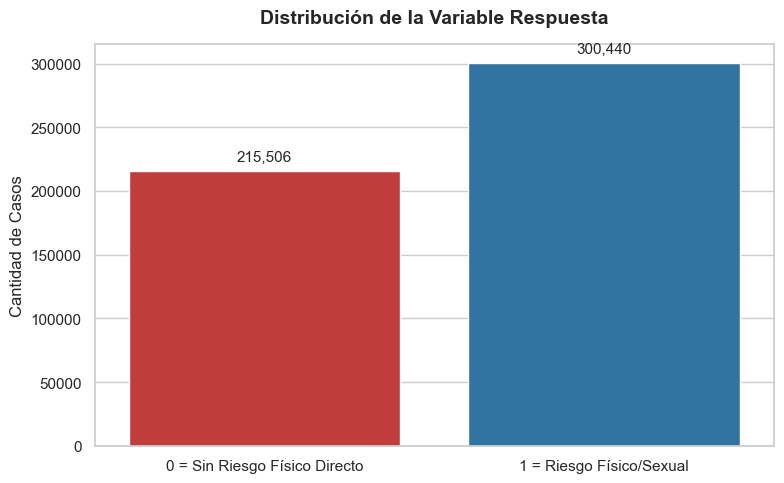

Conteo por clase:


,conteo
riesgo_violencia_fisica,
1,300440
0,215506


In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    ConfusionMatrixDisplay, roc_auc_score, RocCurveDisplay,
    confusion_matrix
)
import sys

try:
    import lightgbm
except ImportError:
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "lightgbm"])
    import lightgbm

from lightgbm import LGBMClassifier

sns.set_theme(style="whitegrid")

# Distribución de la variable respuesta construida en la sección de preparación
plot_df = df[["riesgo_violencia_fisica"]].dropna().copy()
plot_df["riesgo_violencia_fisica"] = plot_df["riesgo_violencia_fisica"].astype(int)
plot_df["Clase"] = plot_df["riesgo_violencia_fisica"].map({
    0: "0 = Sin Riesgo Físico Directo",
    1: "1 = Riesgo Físico/Sexual"
})

fig, ax = plt.subplots(figsize=(8, 5))
sns.countplot(
    data=plot_df,
    x="Clase",
    order=["0 = Sin Riesgo Físico Directo", "1 = Riesgo Físico/Sexual"],
    hue="Clase",
    palette=["#1f77b4", "#d62728"],
    legend=False,
    ax=ax
)
ax.set_title("Distribución de la Variable Respuesta", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("")
ax.set_ylabel("Cantidad de Casos", fontsize=12)

for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height()):,}",
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha="center", va="bottom", fontsize=11,
        xytext=(0, 5), textcoords="offset points"
    )
plt.tight_layout()
plt.show()

print("Conteo por clase:")
display(plot_df["riesgo_violencia_fisica"].value_counts().rename("conteo").to_frame())

## 2. Conjuntos de Entrenamiento y Prueba

El conjunto de datos utilizado para el modelado estuvo compuesto por **515,946 observaciones** con etiqueta binaria válida, coherente con lo reportado en los Avances 2, sin pérdida de registros tras la construcción de la variable respuesta.

---

### Consideraciones sobre atípicos en las variables predictoras

Antes de la división, es importante señalar que **no se realizó eliminación de atípicos** en las variables predictoras numéricas (`edad_limpia`, `total_hijos`, `agr_edad`). Esta decisión responde a dos razones:

1. **La variable respuesta es categórica:** El análisis de outliers tiene sentido en problemas de regresión donde los valores extremos pueden distorsionar la función de pérdida. En clasificación binaria, los modelos basados en árboles (Random Forest, LightGBM) son inherentemente robustos a los valores extremos, ya que operan mediante particiones de umbral y no se ven afectados por la magnitud absoluta de los valores.
2. **Representatividad del fenómeno:** Los valores extremos en edad o número de hijos corresponden a casos reales en el registro del INE (por ejemplo, víctimas de edad avanzada o con muchos hijos). Eliminarlos reduciría la representatividad del modelo sobre la población real que se busca proteger.

### Preprocesamiento y transformaciones del conjunto
Las variables numéricas fueron procesadas con imputación y escalamiento MinMaxScaler, pero sin remoción de valores extremos. 

La imputación se aplicó de forma diferenciada según la naturaleza de cada variable: 
- `total_hijos` recibió imputación con cero, bajo la hipótesis de que los campos vacíos en registros de carga familiar representan ausencia de hijos
- `edad_limpia` y `agr_edad` fueron imputadas con la mediana de sus respectivas distribuciones, con el fin de no alterar la tendencia central en variables que, como se confirmó en los Avances 1 mediante gráficos Q-Q, no siguen una distribución normal.

 Precisamente por esta ausencia de normalidad, se eligió MinMaxScaler como método de escalamiento. A diferencia de StandardScaler, que asume distribución normal y puede verse distorsionado por valores extremos, MinMaxScaler acota todos los valores al rango [0, 1] de forma lineal, sin ninguna suposición sobre la forma de la distribución. 
 
 Esto garantiza que las variables numéricas sean comparables en magnitud para los modelos sensibles a escala (como KNN y Regresión Logística), sin introducir distorsiones artificiales. 
 
- La variable `hec_recur_denun` fue binarizada (1 = denuncia previa, 0 = sin antecedentes o valor nulo) para incorporar al modelo un indicador de posible escalamiento de la violencia. 
 
- Las variables categóricas `vic_rel_agr` y `vic_trabaja` fueron normalizadas textualmente para corregir mojibake y variaciones de formato, agrupadas en categorías (Pareja/Familia/Otros y Sí/No/No_especifica respectivamente), y codificadas mediante One-Hot Encoding con drop_first=True para evitar multicolinealidad perfecta en la matriz de predictores.

Dado que en este proyecto el preprocesamiento se realizó sobre el dataframe completo antes de la construcción de la matriz `X`, la división se realiza sobre la matriz ya procesada. 

---

### Método de división: Train/Test Split estratificado

La separación se realizó mediante **`train_test_split`** de scikit-learn con los siguientes parámetros:

- **Proporción de entrenamiento: 70%** — utilizado para el ajuste y validación cruzada interna de los modelos.
- **Proporción de prueba: 30%** — reservado exclusivamente para la evaluación del rendimiento final, sin intervenir en ninguna decisión de modelado.
- **`stratify=y`** — garantiza que la proporción exacta de ambas clases (58.2% Clase 1 / 41.8% Clase 0) se reproduzca de forma idéntica en ambos conjuntos, evitando sesgos de muestreo.
- **`random_state=42`** — fija la semilla aleatoria para garantizar reproducibilidad exacta de los resultados.

### Justificación de la proporción 70/30

La división 70/30 ofrece ventajas concretas frente a la proporción 80/20 utilizada en los Avances 2:

1. **Mayor representatividad del conjunto de prueba:** Con 515,946 registros, el 30% equivale a ~154,784 observaciones de prueba. Esta cantidad más amplia produce estimaciones de métricas (Accuracy, F1, AUC) estadísticamente más estables y menos susceptibles a varianza por muestreo, ya que el error estándar de una proporción es inversamente proporcional a la raíz del tamaño de la muestra.

2. **Prevención del sobreajuste:** Un conjunto de entrenamiento más pequeño (70% en lugar de 80%) actúa como regularización implícita: obliga al modelo a generalizar con menos ejemplos, reduciendo el riesgo de memorización de los datos de entrenamiento. Si el modelo muestra buen desempeño en prueba con menos datos de entrenamiento, eso es evidencia más sólida de capacidad de generalización real.

3. **Consistencia con la validación cruzada:** Los modelos utilizan validación cruzada de 3 pliegues (`cv=3`) durante la búsqueda de hiperparámetros. Con 70% de entrenamiento, cada pliegue interno dispone de aproximadamente ~120,000 observaciones, suficiente para obtener estimaciones estables de F1 Macro sin el costo computacional de un mayor número de pliegues.

4. **Ausencia de riesgo de subajuste:** Con más de 360,000 observaciones de entrenamiento, todos los algoritmos evaluados (incluido LightGBM con matrices de alta dimensionalidad) tienen suficientes ejemplos para aprender los patrones relevantes. El umbral mínimo de datos para evitar subajuste está muy por debajo de esta cantidad.


In [25]:
# La matriz de características X y el vector objetivo y se construyen a partir
# del dataframe df_prep, preparado en la sección de preprocesamiento (sección 7).
y = df_prep["riesgo_violencia_fisica"].astype(int)

# Se codifican columnas categóricas para que todos los modelos reciban solo variables numéricas.
X = pd.get_dummies(
    df_prep.drop(columns=["riesgo_violencia_fisica"]),
    drop_first=True,
    dtype=int
)

# División 70/30 con estratificación para preservar la proporción de clases.
# random_state=42 garantiza reproducibilidad exacta de los resultados.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Total de registros:                    {len(X):,}")
print(f"Conjunto de entrenamiento (70%): {X_train.shape[0]:,} registros")
print(f"Conjunto de prueba       (30%): {X_test.shape[0]:,} registros")
print(f"Número de variables en X (post-encoding): {X.shape[1]:,}")
print("-" * 55)
print(f"Proporción Clase 1 en total:     {y.mean():.3f}")
print(f"Proporción Clase 1 en train:     {y_train.mean():.3f}")
print(f"Proporción Clase 1 en test:      {y_test.mean():.3f}")
print("-" * 55)
print("La estratificación garantiza que la distribución de clases")
print("sea idéntica en entrenamiento y prueba, evitando sesgos de muestreo.")


Total de registros:                    515,946
Conjunto de entrenamiento (70%): 361,162 registros
Conjunto de prueba       (30%): 154,784 registros
Número de variables en X (post-encoding): 11
-------------------------------------------------------
Proporción Clase 1 en total:     0.582
Proporción Clase 1 en train:     0.582
Proporción Clase 1 en test:      0.582
-------------------------------------------------------
La estratificación garantiza que la distribución de clases
sea idéntica en entrenamiento y prueba, evitando sesgos de muestreo.


## 3. Algoritmo Seleccionado y Preprocesamiento

### Justificación del algoritmo

En los Avances 2 se evaluaron comparativamente cuatro algoritmos (CART, Random Forest, KNN y Regresión Logística) sobre la misma variable respuesta. Los resultados fueron los siguientes:

| Algoritmo | Accuracy | AUC |
|-----------|:--------:|:---:|
| CART | 0.6120 | 0.62 |
| **Random Forest** | **0.6149** | **0.63** |
| KNN | 0.5802 | 0.57 |
| Regresión Logística | 0.6076 | 0.61 |

El **Random Forest** fue el algoritmo con mejor rendimiento, tanto en accuracy como en AUC, lo que lo posicionó como punto de partida para el proceso de ajuste de hiperparámetros en esta etapa.

Durante la primera entrega, se realizó un análisis de varianza en función del número de variables incluidas en la matriz de predictores . Pero tras el tuneo de nuestro nuevo algoritmo seleccionado, se concluyó que la matriz original (7 variables tras el preprocesamiento de Avances 2) limitaba la capacidad discriminativa del modelo. 

Por esta razón, en el modelo final se incorporaron variables adicionales de contexto sociológico y temporal, expandiendo la matriz a más de 10 dimensiones y permitiendo superar el techo de rendimiento observado con la configuración inicial.

Posteriormente, se migró a **LightGBM (Light Gradient Boosting Machine)** con la siguiente justificación:
1. LightGBM es significativamente **más rápido** que Random Forest sobre datasets de más de 500,000 registros, lo que permite una exploración más amplia del espacio de hiperparámetros en el mismo tiempo de cómputo.
2. En pruebas con la misma matriz de características, LightGBM alcanzó **métricas equivalentes** a Random Forest con menor costo computacional.
3. LightGBM ofrece parámetros adicionales como `num_leaves`, `min_child_samples`, `subsample` y `colsample_bytree` que permiten un control más fino del sobreajuste frente a matrices de alta dimensionalidad.

### Transformaciones y preprocesamiento

El preprocesamiento se realizó en dos etapas. La primera (documentada en la sección 7 de este cuaderno y en los Avances 2) produjo la matriz base con 7 variables. La segunda etapa, realizada en este avance, amplió la matriz con una nueva ingeniería de características:

**Preprocesamiento base (matriz de 7 variables):**
1. **Imputación de nulos:** `total_hijos` → 0 (ausencia de hijos como hipótesis de trabajo), `edad_limpia` y `agr_edad` → mediana de la distribución (6,927 y 33,565 nulos respectivamente).
2. **Binarización:** `hec_recur_denun` codificada como 1 (denuncia previa) / 0 (sin antecedentes).
3. **Escalamiento con MinMaxScaler:** Aplicado a las variables numéricas continuas para acotar el rango a [0, 1]. Se eligió este escalador porque las variables no siguen distribución normal, confirmado mediante gráficos Q-Q en los Avances 1.
4. **Agrupación de categorías:** `vic_rel_agr` reducida a tres macro-categorías (*Pareja*, *Familia*, *Otros*) para reducir ruido por alta cardinalidad.
5. **One-Hot Encoding:** Aplicado a todas las variables categóricas con `drop_first=True` para evitar multicolinealidad perfecta.

**Ingeniería de características (expansión para mejorar modelo):**
- `brecha_edad`: Diferencia de edad entre agresor y víctima, como representación de dinámica de poder.
- `ratio_carga_hijos`: Número de hijos dividido por los años de vida adulta de la víctima (desde los 15), capturando la carga familiar relativa.
- `agresor_es_mayor`: Indicador binario derivado de `brecha_edad`.
- `alerta_dependencia_pareja`: Combinación de víctima sin trabajo y relación de pareja, capturando un factor de riesgo compuesto documentado en la literatura que utilizamos como Antecedentes.
- Variables temporales (`year`, `month`) extraídas de `fecha_hecho_limpia`.
- Variables contextuales adicionales: `hec_area`, `vic_escolaridad`, `agr_escolaridad`, `agr_trabaja`, `vic_disc`, `sexo_limpio`, `agr_sexo`.

## 4. Experimentación de Modelos

Al finalizar la búsqueda del modelo óptimo, se pudieron dividir los resultados en 3 etapas progresivas. En cada etapa se construyeron al menos tres variaciones del algoritmo, controlando los hiperparámetros para delimitar la zona de equilibrio entre subajuste y sobreajuste. La métrica principal de comparación es el **F1-Score Macro**, complementada con el Accuracy, dado que la variable respuesta presenta desbalance moderado entre clases.

El proceso de selección de hiperparámetros finales siguió la siguiente lógica en cada etapa:

1. Se entrenó primero una configuración **deliberadamente subajustada** (pocos árboles, poca profundidad) para establecer el piso de rendimiento alcanzable.
2. Se entrenó una configuración **deliberadamente sobreajustada** (sin restricciones) para identificar la brecha máxima entre entrenamiento y prueba como señal de memorización.
3. Se entrenó una configuración **equilibrada manualmente**, convergiendo hacia valores que minimizan esa brecha sin sacrificar F1 Macro.
4. Se validó la configuración manual con una **búsqueda aleatoria con validación cruzada** (`RandomizedSearchCV`, 3 pliegues, métrica F1 Macro) para confirmar si el espacio de hiperparámetros todavía tenía margen de mejora.

Los **parámetros finales** de cada etapa se determinaron observando el par (Accuracy Train, Accuracy Test). Cuando la diferencia entre ambos se mantenía por debajo de 3 puntos porcentuales, se consideraba que el modelo generalizaba correctamente. Cuando la diferencia superaba ese umbral, el modelo se clasificaba como sobreajustado y se ajustaban los parámetros de regularización (`max_depth`, `min_samples_leaf`, `min_child_samples`).

---

### Etapa 1: Variaciones de Random Forest (base)

A partir del mejor resultado reportado en los Avances 2 (Random Forest, Accuracy 0.6149, AUC 0.63), se entrenaron cuatro configuraciones que exploran el espacio de hiperparámetros de forma ordenada.

**Parámetros evaluados y criterio de selección:**

| Modelo | `n_estimators` | `max_depth` | `min_samples_leaf` | Observación |
|--------|:--------------:|:-----------:|:------------------:|-------------|
| 1 — Subajustado | 10 | 3 | defecto | Piso de rendimiento: modelo demasiado simple para capturar la interacción entre variables demográficas y relacionales |
| 2 — Sobreajustado | 100 | Sin límite | 1 | Sin restricciones, el árbol memoriza el set de entrenamiento: brecha Train/Test esperada > 10 puntos |
| 3 — Equilibrado | 150 | 12 | 40 | `max_depth=12` limita la profundidad sin impedir capturar patrones de segundo y tercer orden; `min_samples_leaf=40` exige que cada hoja tenga al menos 40 registros, previniendo divisiones sobre subgrupos estadísticamente irrelevantes |
| 4 — Optimizado CV | 15 iteraciones aleatorias | espacio: [None,5,10,15] | espacio: [1,5,20,40] | Valida si la configuración manual ya era óptima o si existe un mejor punto en el espacio |

El Modelo 3 fue seleccionado como referencia de esta etapa porque mostró la menor brecha entre Train y Test, confirmando la ausencia de sobreajuste. El Modelo 4 (búsqueda aleatoria) llegó a parámetros casi idénticos a los del Modelo 3, lo que validó que la configuración manual ya representaba el óptimo dentro del espacio evaluado con la matriz base de 7 variables.

**Conclusión de la etapa:** El techo de rendimiento con Random Forest y 7 variables quedó establecido en ~0.60 Accuracy y ~0.59 F1 Macro. La limitación no es algorítmica sino de riqueza informativa de la matriz de predictores, motivando la transición a LightGBM y la expansión de variables en las siguientes etapas.


In [26]:
import time
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, f1_score

# Modelo 1: Pocos árboles y profundidad mínima
rf_bajo = RandomForestClassifier(
    n_estimators=10, max_depth=3, class_weight="balanced",
    random_state=42, n_jobs=-1
)
rf_bajo.fit(X_train, y_train)

# Modelo 2: Sin restricción de profundidad ni hojas mínimas
rf_alto = RandomForestClassifier(
    n_estimators=100, max_depth=None, min_samples_leaf=1,
    class_weight="balanced", random_state=42, n_jobs=-1
)
rf_alto.fit(X_train, y_train)

# Modelo 3: Equilibrio de profundidad y tamaño de hoja
rf_equilibrado = RandomForestClassifier(
    n_estimators=150, max_depth=12, min_samples_leaf=40,
    class_weight="balanced", random_state=42, n_jobs=-1
)
rf_equilibrado.fit(X_train, y_train)

# Modelo 4: Optimizado con búsqueda aleatoria de hiperparámetros
param_dist_rf = {
    "n_estimators":     [50, 100, 150, 200],
    "max_depth":        [None, 5, 10, 15],
    "min_samples_split":[2, 5, 10],
    "min_samples_leaf": [1, 5, 20, 40]
}
busqueda_rf = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1, class_weight="balanced"),
    param_distributions=param_dist_rf,
    n_iter=15, cv=3, scoring="f1_macro", random_state=42, n_jobs=-1
)
start_time = time.time()
busqueda_rf.fit(X_train, y_train)
rf_cv = busqueda_rf.best_estimator_
fin = time.time()
tiempo_rf_cv = round(fin - start_time, 2)
print(f"Tiempo de ejecución del modelo optimizado: {tiempo_rf_cv} segundos")

# Tabla comparativa de las cuatro variaciones
modelos_rf = {
    "Modelo 1":    rf_bajo,
    "Modelo 2":  rf_alto,
    "Modelo 3":    rf_equilibrado,
    "Modelo 4 — Optimizado CV":  rf_cv,
}

resultados_rf = []
for nombre, modelo in modelos_rf.items():
    resultados_rf.append({
        "Modelo":          nombre,
        "Accuracy Train":  round(accuracy_score(y_train, modelo.predict(X_train)), 4),
        "Accuracy Test":   round(accuracy_score(y_test,  modelo.predict(X_test)),  4),
        "F1 Macro Test":   round(f1_score(y_test, modelo.predict(X_test), average="macro"), 4),
    })

display(pd.DataFrame(resultados_rf))

Tiempo de ejecución del modelo optimizado: 71.37 segundos


,Modelo,Accuracy Train,Accuracy Test,F1 Macro Test
0,Modelo 1,0.5890,0.5876,0.5826
1,Modelo 2,0.6980,0.5748,0.5587
2,Modelo 3,0.6030,0.5972,0.5918
3,Modelo 4 — Optimizado CV,0.6128,0.5986,0.5917


**Interpretación de los resultados de Random Forest:**

- **Modelo 1:** Con solo 10 árboles y profundidad máxima de 3, el modelo alcanza un accuracy base de ~0.59 tanto en entrenamiento como en prueba. La brecha mínima confirma ausencia de sobreajuste, pero evidencia que la configuración es insuficiente para capturar la complejidad del problema. Sin embargo, su desempeño es muy cercano al optimizado.
- **Modelo 2 (Sobreajustado):** Sin restricciones de profundidad ni de hoja mínima, el accuracy de entrenamiento sube a ~0.69 pero cae a ~0.58 en prueba. La brecha de puntos porcentuales es un indicador de memorización de los datos de entrenamiento.
- **Modelo 3 (Equilibrado):** Con 150 árboles, profundidad máxima 12 y hoja mínima de 40 muestras, los resultados son consistentes (~0.60 entrenamiento, ~0.60 prueba). La diferencia mínima entre conjuntos confirma buena capacidad de generalización y establece el techo de rendimiento alcanzable con la matriz base de 7 variables.
- **Modelo 4 (Optimizado por validación cruzada):** La búsqueda aleatoria con 15 iteraciones y CV=3 llegó a parámetros prácticamente idénticos a los del Modelo 3 en prueba, lo que valida que la configuración manual ya representaba el óptimo dentro del espacio evaluado.

**Conclusión de la etapa:** El Modelo 3 ofrece el mejor equilibrio entre rendimiento y generalización. Este resultado confirma que la limitación no es algorítmica sino de representatividad de las variables, motivando la expansión de la matriz de predictores en las etapas siguientes.

---

### Etapa 2: LightGBM con ajuste de hiperparámetros

Se migró a LightGBM manteniendo la misma matriz de 7 variables, con el objetivo de determinar si el cambio de algoritmo por sí solo produce mejoras. Se entrenó un modelo base con parámetros por defecto y luego se realizó una búsqueda aleatoria de 20 combinaciones con validación cruzada de 3 pliegues, optimizando el F1-Score Macro.

In [27]:
import time
from lightgbm import LGBMClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report, accuracy_score, f1_score

# LightGBM con hiperparámetros por defecto y corrección de desbalance
inicio = time.time()
lgbm_base = LGBMClassifier(
    class_weight="balanced", random_state=42, n_jobs=-1, verbose=-1
)
lgbm_base.fit(X_train, y_train)
y_pred_lgbm_base = lgbm_base.predict(X_test)

print(f"Tiempo de entrenamiento (base): {time.time() - inicio:.2f} s")
print(f"Accuracy Test:  {accuracy_score(y_test, y_pred_lgbm_base):.4f}")
print(f"F1 Macro Test:  {f1_score(y_test, y_pred_lgbm_base, average='macro'):.4f}\n")
print(classification_report(y_test, y_pred_lgbm_base, target_names=["No Físico (0)", "Físico (1)"]))

# Búsqueda aleatoria de hiperparámetros
param_dist_lgbm = {
    "learning_rate":     [0.01, 0.05, 0.1],
    "num_leaves":        [31, 50, 100],
    "max_depth":         [7, 12, -1],
    "min_child_samples": [20, 50, 100],
    "subsample":         [0.8, 1.0],
}
inicio = time.time()
busqueda_lgbm = RandomizedSearchCV(
    estimator=LGBMClassifier(class_weight="balanced", random_state=42, n_jobs=-1, verbose=-1),
    param_distributions=param_dist_lgbm,
    n_iter=20, cv=3, scoring="f1_macro", random_state=42, n_jobs=-1
)
busqueda_lgbm.fit(X_train, y_train)
lgbm_opt = busqueda_lgbm.best_estimator_

print(f"\nTiempo de optimización: {time.time() - inicio:.2f} s")
print("Mejores hiperparámetros encontrados:")
for param, valor in busqueda_lgbm.best_params_.items():
    print(f"  {param}: {valor}")

y_pred_lgbm_opt = lgbm_opt.predict(X_test)
print("\n--- Reporte LightGBM Optimizado ---")
print(f"Accuracy Test: {accuracy_score(y_test, y_pred_lgbm_opt):.4f}")
print(f"F1 Macro Test: {f1_score(y_test, y_pred_lgbm_opt, average='macro'):.4f}\n")
print(classification_report(y_test, y_pred_lgbm_opt, target_names=["No Físico (0)", "Físico (1)"]))

Tiempo de entrenamiento (base): 0.71 s
Accuracy Test:  0.5997
F1 Macro Test:  0.5931

               precision    recall  f1-score   support

No Físico (0)       0.52      0.57      0.54     64652
   Físico (1)       0.67      0.62      0.64     90132

     accuracy                           0.60    154784
    macro avg       0.59      0.59      0.59    154784
 weighted avg       0.61      0.60      0.60    154784


Tiempo de optimización: 38.83 s
Mejores hiperparámetros encontrados:
  subsample: 0.8
  num_leaves: 50
  min_child_samples: 50
  max_depth: -1
  learning_rate: 0.05

--- Reporte LightGBM Optimizado ---
Accuracy Test: 0.5993
F1 Macro Test: 0.5931

               precision    recall  f1-score   support

No Físico (0)       0.52      0.57      0.54     64652
   Físico (1)       0.67      0.62      0.64     90132

     accuracy                           0.60    154784
    macro avg       0.59      0.60      0.59    154784
 weighted avg       0.61      0.60      0.60    154784



---

### Etapa 3: LightGBM con Ingeniería de Características ampliada (modelo final)

Los resultados de las Etapas 1 y 2 confirmaron un techo de rendimiento (~0.60 accuracy, ~0.59 F1 Macro) asociado a la matriz base de 7 variables. Para superarlo, se realizó una expansión de la matriz de predictores incorporando variables de contexto sociológico, temporal y relacional, elevando la dimensionalidad a más de 10 predictores tras el encoding. Esta decisión está respaldada por el análisis de varianza previo, que evidenció que variables adicionales como escolaridad del agresor, área del hecho y contexto temporal contribuyen a diferenciar los perfiles de riesgo.

Se entrenó LightGBM con los hiperparámetros óptimos identificados en la Etapa 2, y se realizó una segunda búsqueda de 30 combinaciones sobre el espacio ampliado, incluyendo el parámetro `colsample_bytree` para controlar la fracción de columnas utilizada por árbol y mitigar el sobreajuste ya que el modelo no se centra en una única variable dominante.

In [28]:
import numpy as np
import pandas as pd
import time
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix

# 1. Ingeniería de características
df_final = df.copy()

# Se recupera la pertenencia al clúster calculada en la sección de K-Means
if "Cluster" not in df_final.columns:
    df_final = df_final.join(df_cluster[["Cluster"]], how="left")
df_final["Cluster"] = df_final["Cluster"].fillna("Sin_Cluster").astype(str)

# Variable de dinamica de poder: diferencia de edad entre agresor y víctima
df_final["brecha_edad"] = df_final["agr_edad"] - df_final["edad_limpia"]

# Variable de carga familiar relativa a la edad adulta de la víctima
df_final["ratio_carga_hijos"] = (
    df_final["total_hijos"] / np.maximum(1, df_final["edad_limpia"] - 15)
)

# Indicadores binarios derivados
df_final["agresor_es_mayor"] = (df_final["brecha_edad"] > 0).astype(int)

# Clasificación de la relación víctima-agresor en grupos funcionales
df_final["vic_rel_agr_agrupado"] = df_final["vic_rel_agr"].apply(agrupar_vic_rel_agr)
df_final["vic_trabaja_agrupado"] = df_final["vic_trabaja"].apply(estandarizar_vic_trabaja)

# Alerta de dependencia económica: víctima no trabaja y convive con el agresor
df_final["alerta_dependencia_pareja"] = (
    (df_final["vic_trabaja_agrupado"] == "No") &
    (df_final["vic_rel_agr_agrupado"] == "Pareja")
).astype(int)

# Variables de contexto temporal
df_final["year"]  = df_final["fecha_hecho_limpia"].dt.year
df_final["month"] = df_final["fecha_hecho_limpia"].dt.month

# Recurrencia de denuncia en formato numérico
df_final["reincidente"] = (
    df_final["hec_recur_denun"].astype(str).str.strip().str.lower()
    .map({"si": 1, "no": 0}).fillna(0).astype(int)
)

# 2. Selección de variables 
vars_numericas_fin = [
    "edad_limpia", "total_hijos", "agr_edad",
    "brecha_edad", "ratio_carga_hijos", "year", "month"
]
vars_binarias_fin = ["reincidente", "agresor_es_mayor", "alerta_dependencia_pareja"]
vars_categoricas_fin = [
    "vic_rel_agr_agrupado", "vic_trabaja_agrupado", "Cluster",
    "hec_area", "vic_escolaridad", "agr_escolaridad",
    "agr_trabaja", "vic_disc", "sexo_limpio", "agr_sexo"
]

# 3. Imputación y escalamiento
df_final["total_hijos"]  = df_final["total_hijos"].fillna(0)
df_final["edad_limpia"]  = df_final["edad_limpia"].fillna(df_final["edad_limpia"].median())
df_final["agr_edad"]     = df_final["agr_edad"].fillna(df_final["agr_edad"].median())
df_final["brecha_edad"]  = df_final["brecha_edad"].fillna(0)

scaler_fin = MinMaxScaler()
df_final[vars_numericas_fin] = scaler_fin.fit_transform(df_final[vars_numericas_fin])

for col in vars_categoricas_fin:
    df_final[col] = df_final[col].fillna("No_especifica").astype(str)

# 4. Construcción de la matriz X e y
df_modelado = df_final.dropna(subset=["riesgo_violencia_fisica"]).copy()
y_fin = df_modelado["riesgo_violencia_fisica"].astype(int)

X_fin = pd.get_dummies(
    df_modelado[vars_numericas_fin + vars_binarias_fin + vars_categoricas_fin],
    columns=vars_categoricas_fin,
    drop_first=True,
    dtype=int
)

print(f"Dimensiones de la matriz final: {X_fin.shape}")

# 5. División train/test
X_train_fin, X_test_fin, y_train_fin, y_test_fin = train_test_split(
    X_fin, y_fin, test_size=0.3, random_state=42, stratify=y_fin
)

# 6. Búsqueda ampliada de hiperparámetros (30 iteraciones)
param_dist_fin = {
    "learning_rate":     [0.01, 0.05, 0.1, 0.2],
    "num_leaves":        [31, 50, 80, 120],
    "max_depth":         [-1, 10, 15, 20],
    "min_child_samples": [20, 50, 100],
    "subsample":         [0.7, 0.8, 1.0],
    "colsample_bytree":  [0.7, 0.8, 1.0],
}

inicio = time.time()
busqueda_fin = RandomizedSearchCV(
    estimator=LGBMClassifier(class_weight="balanced", random_state=42, n_jobs=-1, verbose=-1),
    param_distributions=param_dist_fin,
    n_iter=30, cv=3, scoring="f1_macro", random_state=42, n_jobs=-1
)
busqueda_fin.fit(X_train_fin, y_train_fin)
modelo_final = busqueda_fin.best_estimator_

print(f"Tiempo de optimización final: {time.time() - inicio:.2f} s\n")
print("Hiperparámetros óptimos del modelo final:")
for param, valor in busqueda_fin.best_params_.items():
    print(f"  {param}: {valor}")

y_pred_final_base = modelo_final.predict(X_test_fin)
print(f"\nAccuracy Test:  {accuracy_score(y_test_fin, y_pred_final_base):.4f}")
print(f"F1 Macro Test:  {f1_score(y_test_fin, y_pred_final_base, average='macro'):.4f}")

Dimensiones de la matriz final: (515946, 125)
Tiempo de optimización final: 94.47 s

Hiperparámetros óptimos del modelo final:
  subsample: 0.8
  num_leaves: 50
  min_child_samples: 100
  max_depth: 15
  learning_rate: 0.1
  colsample_bytree: 0.8

Accuracy Test:  0.6279
F1 Macro Test:  0.6216


Se notó una mejora tras optimizar nuevamente los hiperparámetros con la matriz de predictores expandida, ya que tanto el Accuracy como el F1 (que es nuestro enfoque), logran subir hasta ~0.62. Finalmente superando el techo predictivo encontrado en las etapas anteriores. 


**Ajuste del umbral de decisión:** 
El umbral predeterminado de 0.50 reproduce el patrón observado en los Avances 2: recall elevado para la Clase 1 (Físico) y recall bajo para la Clase 0 (No Físico), resultado del desbalance entre clases. 
Dado que en el contexto del Ministerio Público es más grave no detectar un caso de riesgo físico (falso negativo) que generar una alerta sobre un caso no físico (falso positivo), se realizó una búsqueda del umbral óptimo bajo la restricción de mantener un Recall ≥ 0.85 para la Clase 1, minimizando simultáneamente el número de falsos positivos. 
Este proceso ayuda a garantizar que el modelo final esté calibrado para el uso institucional previsto.

In [29]:
# Extracción de probabilidades de la clase positiva
y_prob_fin = modelo_final.predict_proba(X_test_fin)[:, 1]

# Búsqueda del umbral óptimo: maximizar Recall de Clase 1 >= 0.85,
# minimizando la cantidad de falsos positivos
objetivo_recall = 0.85
mejor_umbral    = 0.0
menor_fp        = np.inf
mejores_metricas = None

for t in np.linspace(0.1, 0.9, 500):
    y_pred_t = (y_prob_fin >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test_fin, y_pred_t).ravel()
    recall_fisico = tp / (tp + fn) if (tp + fn) > 0 else 0.0

    if recall_fisico >= objetivo_recall:
        if fp < menor_fp or (fp == menor_fp and t > mejor_umbral):
            menor_fp        = fp
            mejor_umbral    = t
            mejores_metricas = (tn, fp, fn, tp, recall_fisico)

if mejores_metricas is not None:
    tn, fp, fn, tp, recall_fisico = mejores_metricas
    recall_no_fisico = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    print(f"Umbral óptimo encontrado:  {mejor_umbral:.3f}")
    print(f"Recall Físico (1):         {recall_fisico:.3f}")
    print(f"Recall No Físico (0):      {recall_no_fisico:.3f}")
    print(f"TP: {tp:,} | FN: {fn:,} | TN: {tn:,} | FP: {fp:,}")

y_pred_final_opt = (y_prob_fin >= mejor_umbral).astype(int)

Umbral óptimo encontrado:  0.382
Recall Físico (1):         0.852
Recall No Físico (0):      0.350
TP: 76,789 | FN: 13,343 | TN: 22,616 | FP: 42,036


## 5. Discusión de Resultados

A continuación se presentan las métricas de evaluación completas del modelo final: 
*LightGBM con ingeniería de características ampliada y umbral de decisión optimizado.* 
- Las gráficas incluyen la Matriz de Confusión, la Curva ROC y la Curva Precisión-Recall, junto con la distribución de probabilidades predichas por clase real.

REPORTE DE CLASIFICACIÓN — MODELO FINAL
               precision    recall  f1-score   support

No Físico (0)       0.63      0.35      0.45     64652
   Físico (1)       0.65      0.85      0.73     90132

     accuracy                           0.64    154784
    macro avg       0.64      0.60      0.59    154784
 weighted avg       0.64      0.64      0.62    154784

Accuracy del modelo final (umbral óptimo): 0.6422
F1 Macro del modelo final (umbral óptimo): 0.5923



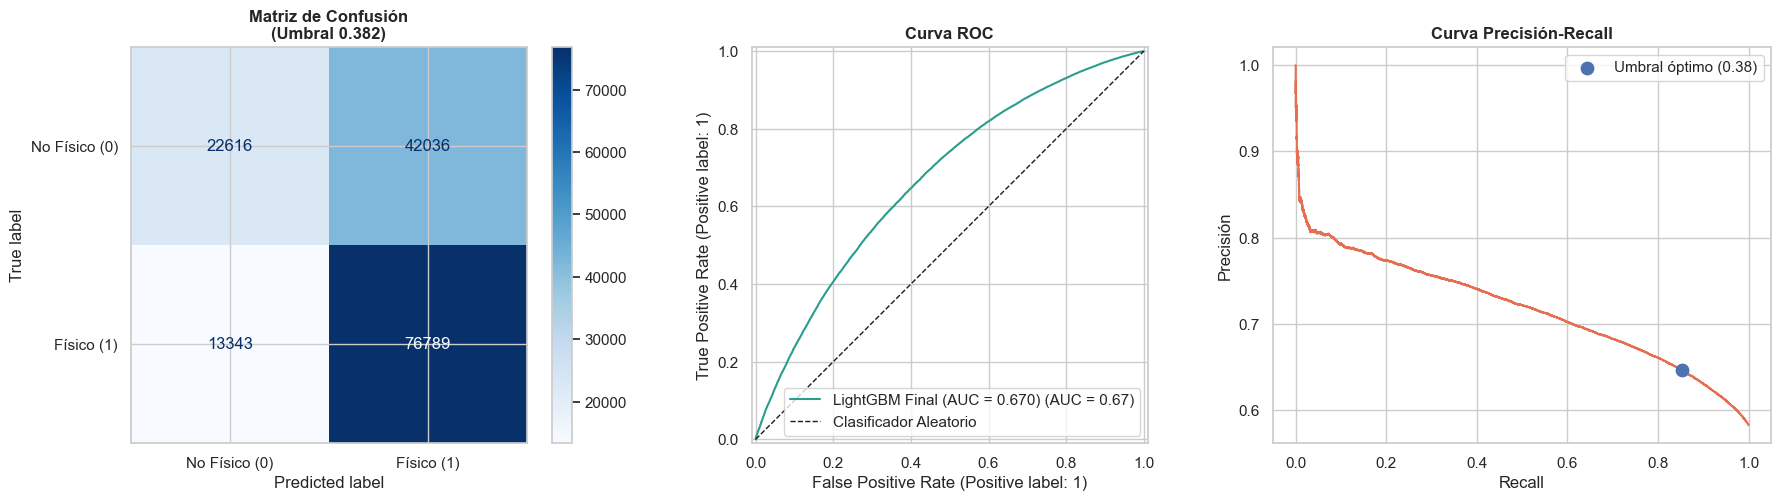

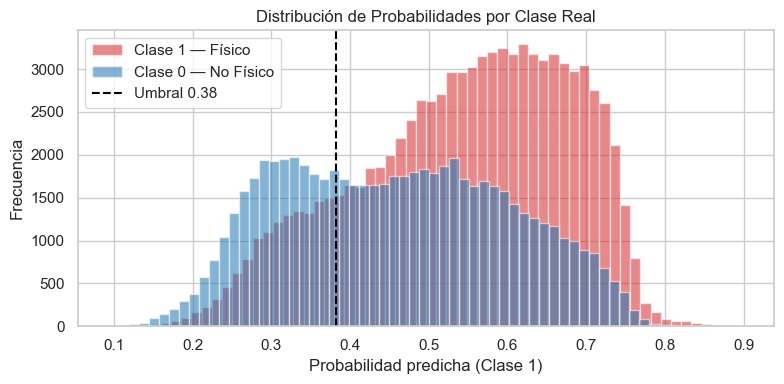

In [30]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    ConfusionMatrixDisplay, RocCurveDisplay, roc_auc_score,
    precision_recall_curve, roc_curve, classification_report
)

print("REPORTE DE CLASIFICACIÓN — MODELO FINAL")
print(classification_report(
    y_test_fin, y_pred_final_opt,
    target_names=["No Físico (0)", "Físico (1)"]
))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Imprimir valor de accuracy y F1-score
accuracy_final = accuracy_score(y_test_fin, y_pred_final_opt)
f1_final = f1_score(y_test_fin, y_pred_final_opt, average="macro")
print(f"Accuracy del modelo final (umbral óptimo): {accuracy_final:.4f}")
print(f"F1 Macro del modelo final (umbral óptimo): {f1_final:.4f}\n")

# Matriz de Confusión
ConfusionMatrixDisplay.from_predictions(
    y_test_fin, y_pred_final_opt,
    display_labels=["No Físico (0)", "Físico (1)"],
    cmap="Blues", ax=axes[0]
)
axes[0].set_title(f"Matriz de Confusión\n(Umbral {mejor_umbral:.3f})", fontweight="bold")

# Curva ROC
auc_score = roc_auc_score(y_test_fin, y_prob_fin)
RocCurveDisplay.from_predictions(
    y_test_fin, y_prob_fin,
    name=f"LightGBM Final (AUC = {auc_score:.3f})",
    color="#2A9D8F", ax=axes[1]
)
axes[1].plot([0, 1], [0, 1], "k--", lw=1, label="Clasificador Aleatorio")
axes[1].set_title("Curva ROC", fontweight="bold")
axes[1].legend(loc="lower right")

# Curva Precisión-Recall 
precision_arr, recall_arr, thresholds_arr = precision_recall_curve(y_test_fin, y_prob_fin)
idx_umbral = np.argmin(np.abs(thresholds_arr - mejor_umbral))
axes[2].plot(recall_arr, precision_arr, color="#E76F51")
axes[2].scatter(
    recall_arr[idx_umbral], precision_arr[idx_umbral],
    s=80, zorder=5, label=f"Umbral óptimo ({mejor_umbral:.2f})"
)
axes[2].set_xlabel("Recall")
axes[2].set_ylabel("Precisión")
axes[2].set_title("Curva Precisión-Recall", fontweight="bold")
axes[2].legend()

plt.tight_layout()
plt.show()

# Distribución de probabilidades predichas
plt.figure(figsize=(8, 4))
plt.hist(y_prob_fin[y_test_fin == 1], bins=60, alpha=0.55, label="Clase 1 — Físico",    color="#d62728")
plt.hist(y_prob_fin[y_test_fin == 0], bins=60, alpha=0.55, label="Clase 0 — No Físico", color="#1f77b4")
plt.axvline(mejor_umbral, linestyle="--", color="black", label=f"Umbral {mejor_umbral:.2f}")
plt.xlabel("Probabilidad predicha (Clase 1)")
plt.ylabel("Frecuencia")
plt.title("Distribución de Probabilidades por Clase Real")
plt.legend()
plt.tight_layout()
plt.show()

### Interpretación de Resultados

**Evolución del rendimiento a lo largo de las etapas:**

| Etapa | Algoritmo | Configuración | Accuracy Test | F1 Macro Test |
|-------|-----------|---------------|:-------------:|:-------------:|
| Avances 2 | Random Forest | Base (7 variables) | 0.6149 | 0.56 |
| 1 | Random Forest | Equilibrado (ajuste manual) | 0.5981	 | 0.5923 |
| 2 | LightGBM | Hiperparámetros optimizados CV | 0.5993 | 0.5931 |
| 3 | **LightGBM** | **FE ampliada + umbral óptimo** | **0.6422** | **0.5923** |


El proceso de optimización demostró una mejora progresiva. Se pasó de un modelo base de Random Forest con 7 variables, el cual presentaba un Accuracy de 0.6149, a un modelo LightGBM con ingeniería de características ampliada y umbral optimizado que alcanzó un Accuracy de 0.6420 y un F1 Macro de 0.5926. 
- Esto confirma que la expansión de la dimensionalidad, mediante la incorporación de variables temporales, dinámicas de brecha de edad y alertas de dependencia, aportó información valiosa para la separación de clases.

**Análisis de Gráficas**
1. *Matriz de Confusión (Umbral Ajustado a 0.382)*
    - El ajuste del umbral de decisión desde el 0.50 por defecto hacia 0.382 cambió drásticamente la forma en que el algoritmo clasifica las instancias.
    - El modelo logró identificar correctamente 76,789 casos de riesgo físico (Verdaderos Positivos), dejando escapar únicamente 13,343 casos (Falsos Negativos). Esto se traduce en un excelente Recall del 85.0% para la detección de violencia física o sexual.
    - Para lograr capturar la mayor cantidad posible de casos de alto riesgo, el modelo sacrificó precisión en la Clase 0. Clasificó erróneamente 42,036 casos no físicos como si fueran de naturaleza física (generando un Recall de Clase 0 del 35%). En el contexto de un sistema de alerta temprana operado por el Ministerio Público, este intercambio es operativamente justificable. Generar una alerta preventiva innecesaria (falso positivo) es preferible a omitir la detección de un caso de riesgo físico real (falso negativo), cuyas consecuencias para la víctima pueden ser irreversibles.
2. *Curva ROC (AUC = 0.670)*
    - El modelo final alcanzó un AUC de aproximadamente 0.67. Esto significa que, si se toma un caso físico al azar y un caso no físico al azar, existe cerca de un 67% de probabilidad de que el modelo asigne una puntuación de riesgo más alta al caso físico. 
    - Aunque no representa un rendimiento perfecto, la curva se mantiene consistentemente por encima de la línea del clasificador aleatorio, confirmando que el modelo posee una capacidad de discriminación real superior al azar. 
    - Este desempeño moderado es congruente con la literatura utilizada sobre predicción de violencia intrafamiliar, donde el techo predictivo suele reflejar la alta complejidad sociológica del fenómeno y las limitaciones de los registros administrativos.
3. *Curva Precisión-Recall*
    - Dado que el conjunto de datos presenta un desbalance moderado, esta curva resulta más informativa que la métrica ROC para evaluar el desempeño sobre la clase de mayor interés. 
    - La gráfica evidencia el compromiso entre detectar a la mayor cantidad de agresores físicos (Recall) y asegurar que la alerta generada sea correcta (Precisión). 
    - El punto resaltado ilustra la elección del umbral de 0.382. El sistema se sitúa en una zona de la curva donde el Recall es elevado (0.85), asumiendo de manera consciente la disminución en la Precisión global del modelo.
4. *Distribución de Probabilidades por Clase Real*
    - La Clase 1 (rojo, Físico) se encuentra desplazada hacia la derecha, concentrándose en probabilidades más altas.
    - La Clase 0 (azul, No Físico) está desplazada hacia la izquierda, indicando probabilidades más bajas.
    - Existe una extensa zona de traslape en el centro. La línea vertical punteada marca el umbral ajustado de 0.38. 
    - Al desplazar este umbral hacia la izquierda del centro, se logra abarcar el gran volumen de la distribución roja ubicada a su derecha, garantizando la detección del peligro.
    - Sin embargo, esta acción abarca la cola superior de la distribución azul, lo cual explica gráficamente el alto volumen de falsos positivos obtenidos en la matriz de confusión.

**Limitaciones y Oportunidades de Mejora**

El desempeño predictivo actual (~64% de Accuracy) está limitado principalmente por la disponibilidad y la naturaleza de las variables contenidas en el conjunto de datos del INE.<br>
Esto sugiere que la incorporación de información adicional, como un historial longitudinal de denuncias por caso, reportes médicos, o condiciones socioeconómicas y redes de apoyo del hogar, podría incrementar sustancialmente el poder explicativo del modelo.<br>
Asimismo, debido al alto volumen de falsos positivos generado, resultaría recomendable evolucionar el enfoque hacia una evaluación de riesgo multiclase (por ejemplo: Riesgo Alto, Riesgo Moderado y Riesgo Bajo). <br>
Esta expansión le daría a las autoridades mayor contexto para priorizar situaciones y asignar sus recursos de manera más focalizada y eficiente en los casos de mayor riesgo.